# **Fundamentos de Analítica de Datos I - Parcial práctico**

### *Valentina Giraldo Gaviria*

Una compañía de comestibles está interesada en predecir el comportamiento de las ventas (en unidades) de sus dos productos estrella. Fuimos contratados para generar un modelo que permita pronosticar las ventas del siguiente mes de cada uno de esos dos productos. La base de datos disponible en el archivo Examen.csv tiene la información de cada uno de los productos desde junio de 2014.

Su misión es encontrar el mejor modelo para pronosticar cada una de las series. Usted debe entregar un informe escrito de no más de cuatro páginas que presente los resultados al cliente y cuente el proceso para llegar a los pronósticos.

## **1. Carga de paquetes**

In [5]:
# =======================================
# 1. Instalación de paquetes externos
# =======================================
!pip install bayesian-optimization
!pip install optuna

# =======================================
# 2. Librerías estándar de Python
# =======================================
import logging
import random
import warnings

# =======================================
# 3. Manejo numérico y de datos
# =======================================
import numpy as np
import pandas as pd

# =======================================
# 4. Visualización
# =======================================
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# =======================================
# 5. Modelado de series de tiempo (statsmodels)
# =======================================
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.api import VAR

from statsmodels.stats.diagnostic import het_arch
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import jarque_bera
from statsmodels.sandbox.stats.runs import runstest_1samp

# =======================================
# 6. Otras librerías estadísticas / ML
# =======================================
from bayes_opt import BayesianOptimization
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from scipy import stats
import optuna

# =======================================
# 7. Semillas aleatorias (reproducibilidad)
# =======================================
random.seed(123)
np.random.seed(123)

# silenciar warnings si es necesario
warnings.filterwarnings("ignore")

## **2. Carga de datos**

En primer lugar, se cargaron los datos del archivo Examen.csv y se transformó la columna Mes en un índice de tipo fecha con frecuencia mensual.

In [6]:
# Se lee el archivo con las ventas mensuales de los dos productos.
# index_col=0 indica que la primera columna es un índice genérico que no se usará.
data = pd.read_csv("/content/sample_data/Examen (1).csv",sep=",", index_col=0)

# Se crea una columna de fechas mensuales (primer día de cada mes),
# comenzando en junio de 2014 y con la misma longitud del DataFrame.
data['Mes'] = pd.date_range(start='2014-06-1', periods=len(data), freq='MS')

# Se establece la columna 'Mes' como índice temporal de la serie.
data.set_index('Mes', inplace=True)

# Vista rápida de las primeras filas
data.head()

,producto1,producto2
Mes,,
2014-06-01,500.000000,200.000000
2014-07-01,497.400893,210.686220
2014-08-01,478.605317,222.018584
2014-09-01,486.454125,233.920990
2014-10-01,479.695678,238.402098


In [7]:
# imprimiendo el tamano del dataframe
print(data.shape)

(127, 2)


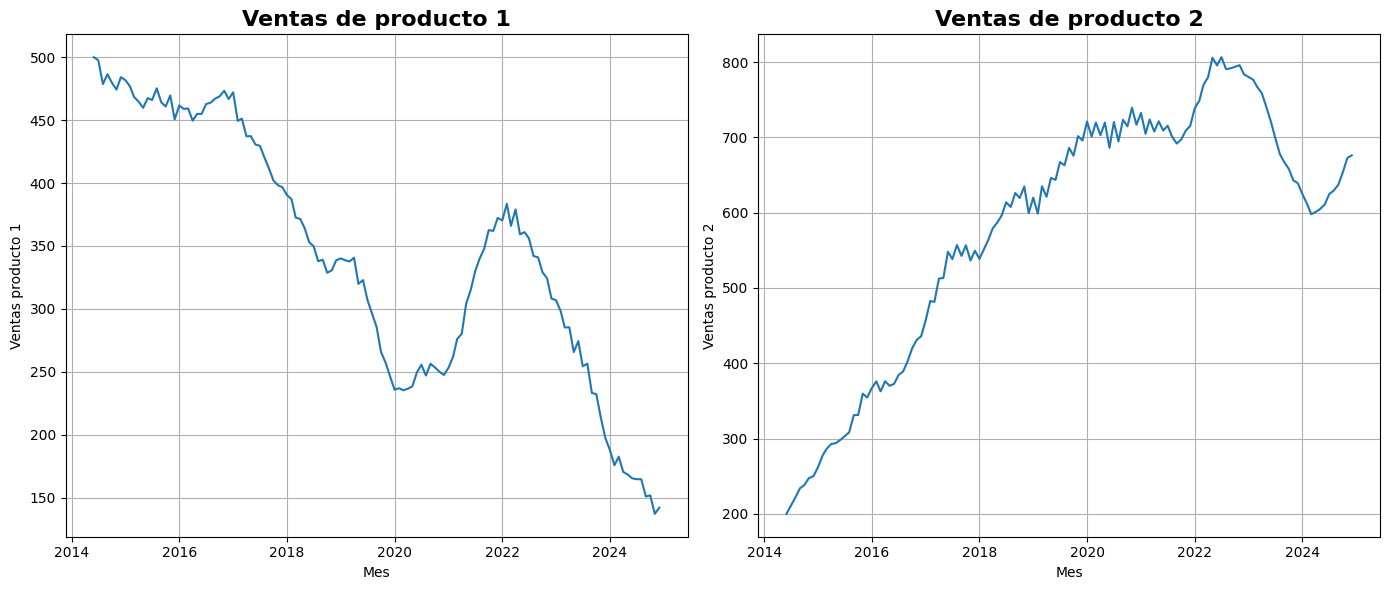

In [8]:
# =======================================
# Gráficos de las series de ventas
# =======================================

# Se crean dos subgráficos: uno para cada producto.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Serie de ventas del producto 1
axes[0].set_title("Ventas de producto 1", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Ventas producto 1")
axes[0].plot(data.index, data["producto1"])  # Usar el índice para el eje X
axes[0].grid()

# Serie de ventas del producto 2
axes[1].set_title("Ventas de producto 2", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Ventas producto 2")
axes[1].plot(data.index, data["producto2"])  # Usar el índice para el eje X
axes[1].grid()

plt.tight_layout()
plt.show()

## **3. Encontrando los componentes de una serie de tiempo**

A continuación se realiza una descomposición de la serie temporal de ambos productos para hallar los cuatro componentes de una serie: tendencia, estacionalidad, factor cíclico y componente aleatorio.

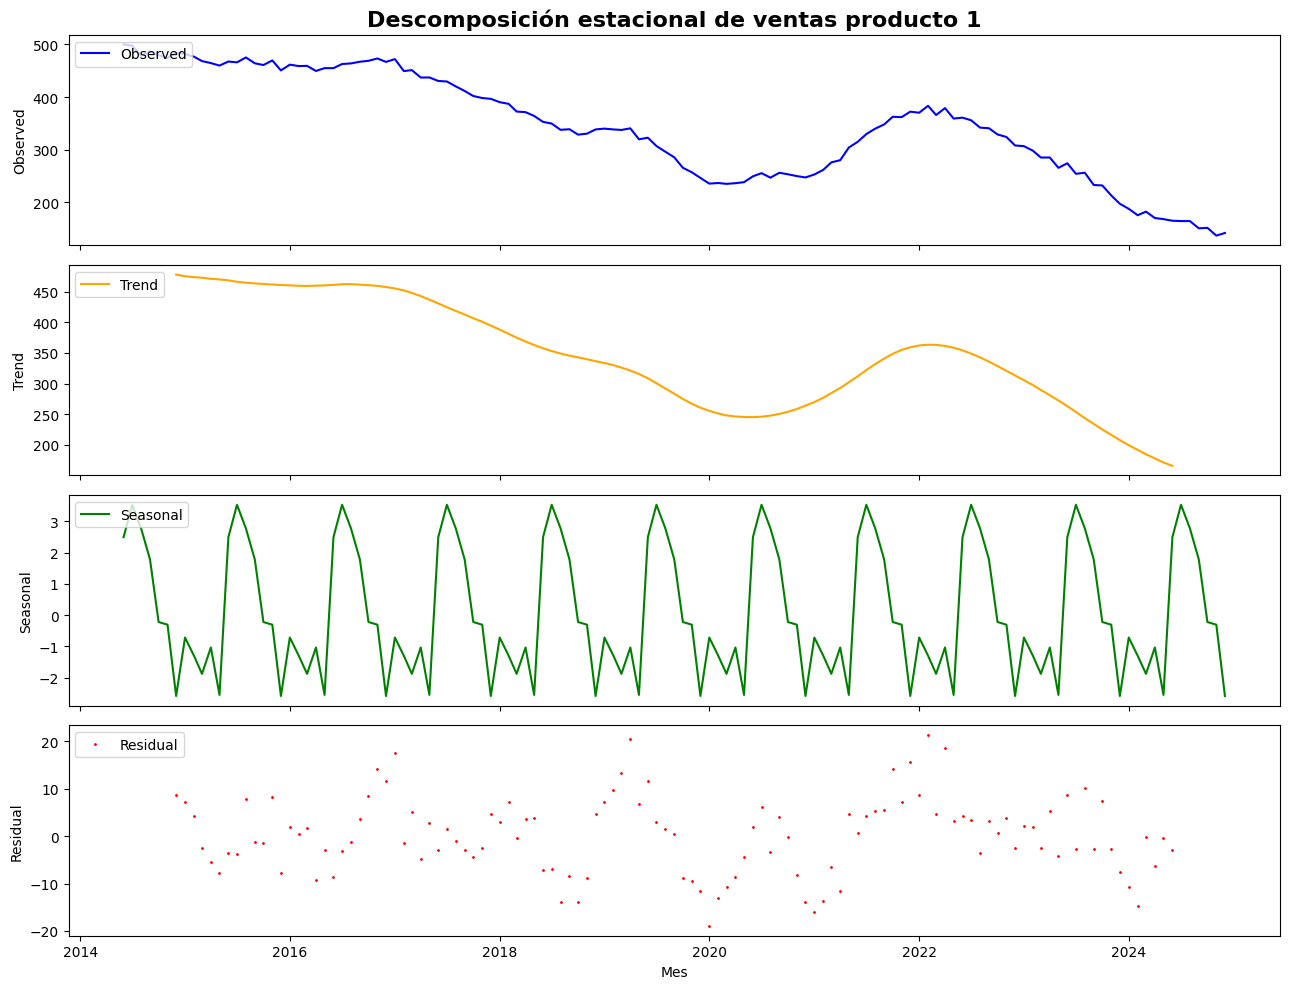

In [9]:
# =======================================
# 3. Descomposición clásica de la serie
#    (tendencia, estacionalidad y residuales)
# =======================================

# --- Producto 1 ---
# Se descompone la serie bajo un esquema aditivo:
td_componentes = seasonal_decompose(data["producto1"], model="additive")

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

# Serie observada
axes[0].plot(td_componentes.observed, label='Observed', color='blue')
axes[0].set_ylabel('Observed')
axes[0].legend(loc='upper left')
axes[0].set_title('Descomposición estacional de ventas producto 1',fontsize=16, fontweight='bold')

# Componente tendencia
axes[1].plot(td_componentes.trend, label='Trend', color='orange')
axes[1].set_ylabel('Trend')
axes[1].legend(loc='upper left')

# Componente estacional
axes[2].plot(td_componentes.seasonal, label='Seasonal', color='green')
axes[2].set_ylabel('Seasonal')
axes[2].legend(loc='upper left')

# Componente residual
axes[3].plot(td_componentes.resid, label='Residual', color='red', linestyle='None', marker='o', markersize=1)
axes[3].set_ylabel('Residual')
axes[3].legend(loc='upper left')
axes[3].set_xlabel('Mes')

fig.tight_layout()
plt.show()

##### **Producto 1 – Descomposición estacional**

- **Tendencia :** La tendencia revela un comportamiento decreciente a lo largo del tiempo, indicando que las ventas del producto 1 han disminuido de manera sostenida durante gran parte del período. Se observa una recuperación entre 2020 y 2022, seguida nuevamente por una caída hasta 2024.

- **Estacionalidad:** El componente estacional muestra un patrón cíclico estable y repetitivo cada 12 meses. Dado que la amplitud estacional se mantiene relativamente constante, esto sugiere que la estacionalidad es de tipo aditivo.

- **Residuales:** Los residuales no se comportan como ruido blanco puro. Se observan ciertos agrupamientos y picos que indican presencia de autocorrelación o estructura no capturada por la descomposición clásica. Esto sugiere que la serie no es totalmente aditiva o que requiere un modelo más flexible para describir su dinámica.

Ahora analizamos la descomposición de la serie de ventas del producto 2.

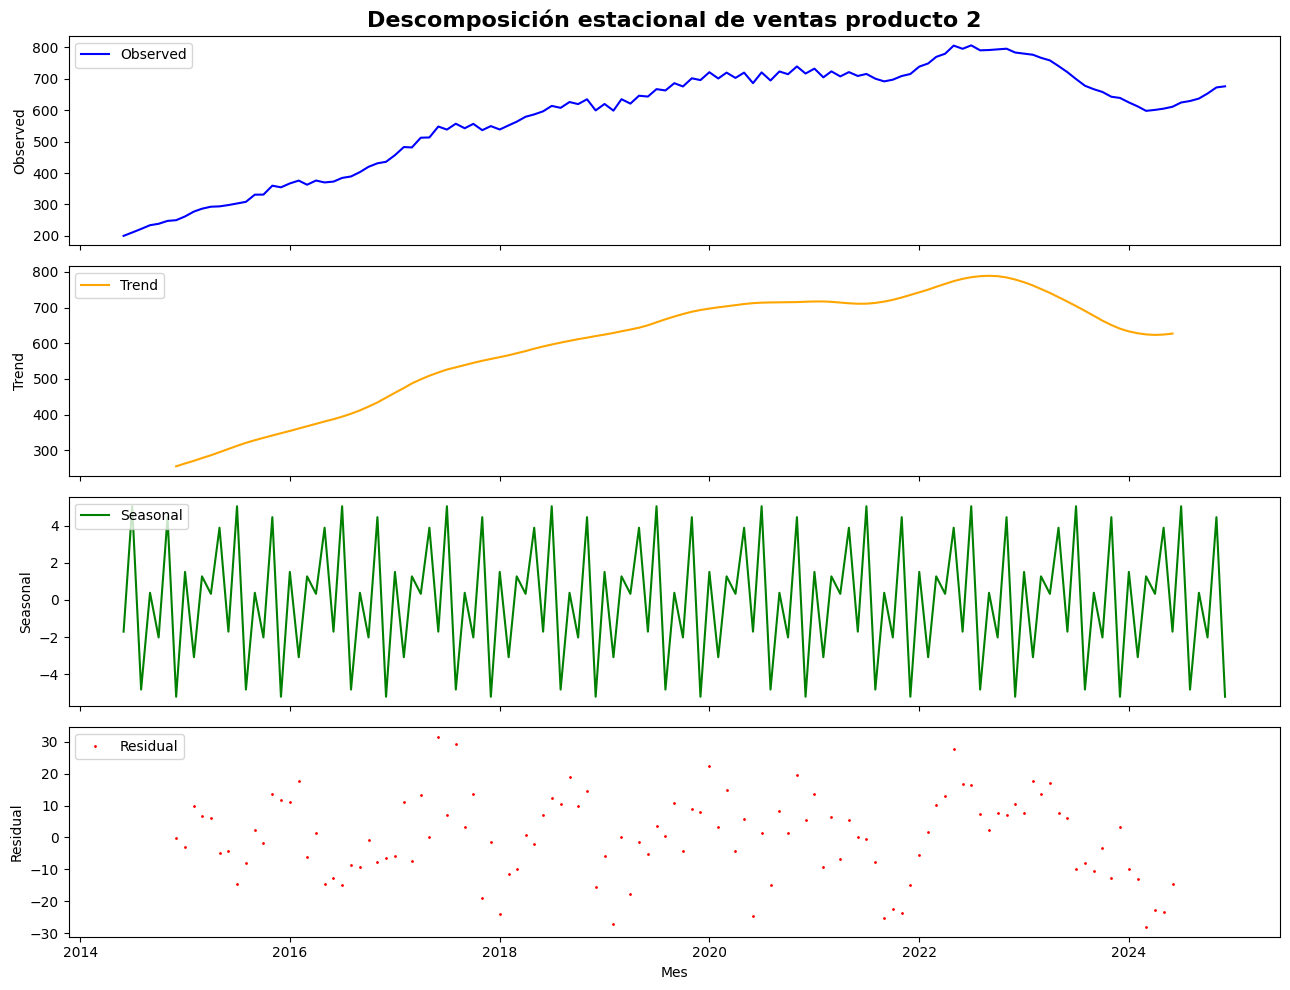

In [10]:
# --- Producto 2 --
td_componentes = seasonal_decompose(data["producto2"], model="additive")

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

# Serie observada
axes[0].plot(td_componentes.observed, label='Observed', color='blue')
axes[0].set_ylabel('Observed')
axes[0].legend(loc='upper left')
axes[0].set_title('Descomposición estacional de ventas producto 2',fontsize=16, fontweight='bold')

# Componente tendencia
axes[1].plot(td_componentes.trend, label='Trend', color='orange')
axes[1].set_ylabel('Trend')
axes[1].legend(loc='upper left')

# Componente estacional
axes[2].plot(td_componentes.seasonal, label='Seasonal', color='green')
axes[2].set_ylabel('Seasonal')
axes[2].legend(loc='upper left')

# Componente residual
axes[3].plot(td_componentes.resid, label='Residual', color='red', linestyle='None', marker='o', markersize=1)
axes[3].set_ylabel('Residual')
axes[3].legend(loc='upper left')
axes[3].set_xlabel('Mes')


fig.tight_layout()
plt.show()

##### **Producto 2 – Descomposición estacional**

- **Tendencia :** La tendencia muestra un incremento sostenido desde 2014 hasta aproximadamente 2022, indicando crecimiento prolongado en las ventas del producto 2. Entre 2022 y 2024 aparece una caída moderada con una ligera recuperación posterior. Esto evidencia un patrón de tendencia más marcado y persistente que en el producto 1.

- **Estacionalidad:** La estacionalidad revela un patrón mensual repetitivo y estable a lo largo del tiempo. La magnitud del componente estacional también es relativamente constante, lo que apunta nuevamente a una estacionalidad aditiva.

- **Residuales:** Los residuales presentan variabilidad considerable y muestran agrupamientos temporales, lo que evidencia que no son completamente aleatorios. Esto indica que aún existe estructura en la serie sin capturar, posiblemente relacionada con autocorrelación en los errores

## **4. Protocolo de evaluación**

Para evaluar el desempeño de los modelos de pronóstico se utilizó un protocolo de ventana móvil. Este esquema simula el uso real del modelo en producción: se entrena con la información disponible hasta un cierto mes y se pronostica el mes siguiente.

La base de datos cuenta con 127 observaciones mensuales. De ellas, se utilizan 115 observaciones para entrenar en cada iteración y se evalúa el pronóstico sobre el mes inmediatamente posterior. Desplazando la ventana un mes hacia adelante, se generan 12 ventanas móviles, lo que permite obtener un RMSE promedio robusto para cada modelo y producto.

De esta forma, la comparación entre modelos se basa en su capacidad para pronosticar correctamente datos que no se usaron en el ajuste, lo que reduce el riesgo de sobreajuste.

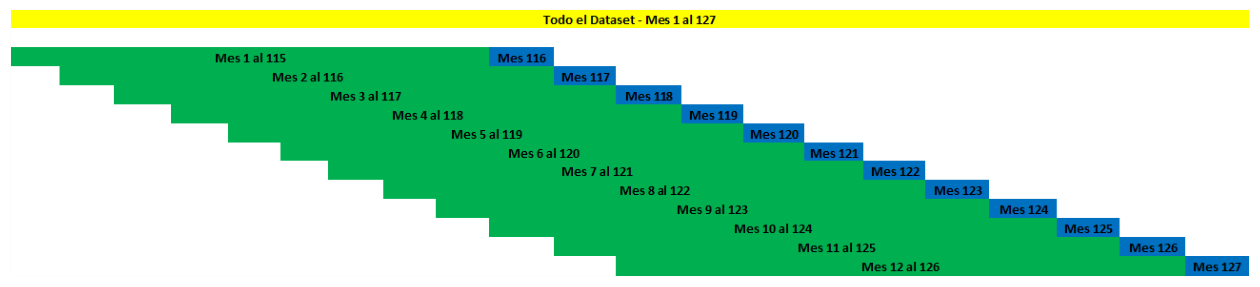

In [11]:
# =======================================
# 4. Protocolo de evaluación: ventana móvil
# =======================================

# Protocolo:
# - Se usan ventanas de 115 observaciones para entrenar.
# - En cada iteración se pronostica el siguiente mes (h=1).
# - La ventana se desplaza un mes hacia adelante, generando 12 ventanas en total.
# - Sobre los 12 pronósticos fuera de muestra se calcula el RMSE promedio.

# Cargamos el esquema ilustrativo del protocolo (archivo PNG)
img = mpimg.imread('/content/sample_data/Protocolo_evaluación.png')
plt.figure(figsize=(16,4))
plt.imshow(img)
plt.axis('off')
plt.show()


## **5. Estimación de modelos**

### **5.1. Promedio móvil + ventana móvi**


===== RMSE promedio por orden - Producto 1 =====
 MA(2): 7.9258
 MA(3): 11.0954
 MA(4): 14.4556
 MA(5): 18.0020
 MA(6): 21.6122

>>> Mejor orden MA para Producto 1: MA(2)


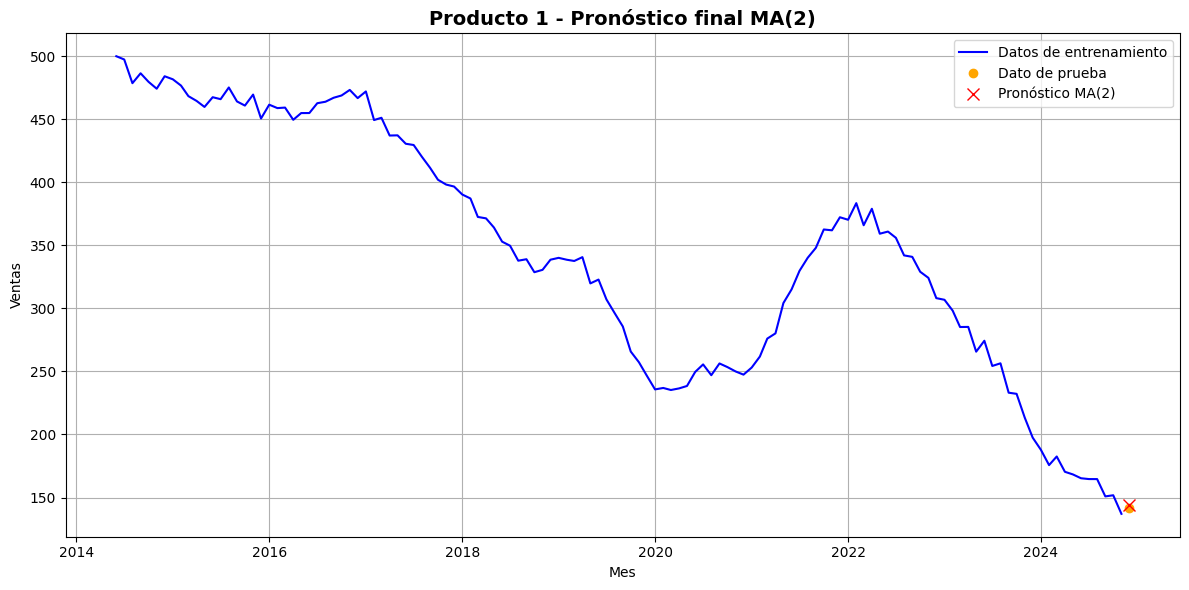


Pronóstico final (MA(2)): 144.42
Dato real:                        141.99
Diferencia pronóstico - real:     2.43

===== RMSE promedio por orden - Producto 2 =====
 MA(2): 14.4099
 MA(3): 18.4945
 MA(4): 22.3360
 MA(5): 25.7288
 MA(6): 29.0045

>>> Mejor orden MA para Producto 2: MA(2)


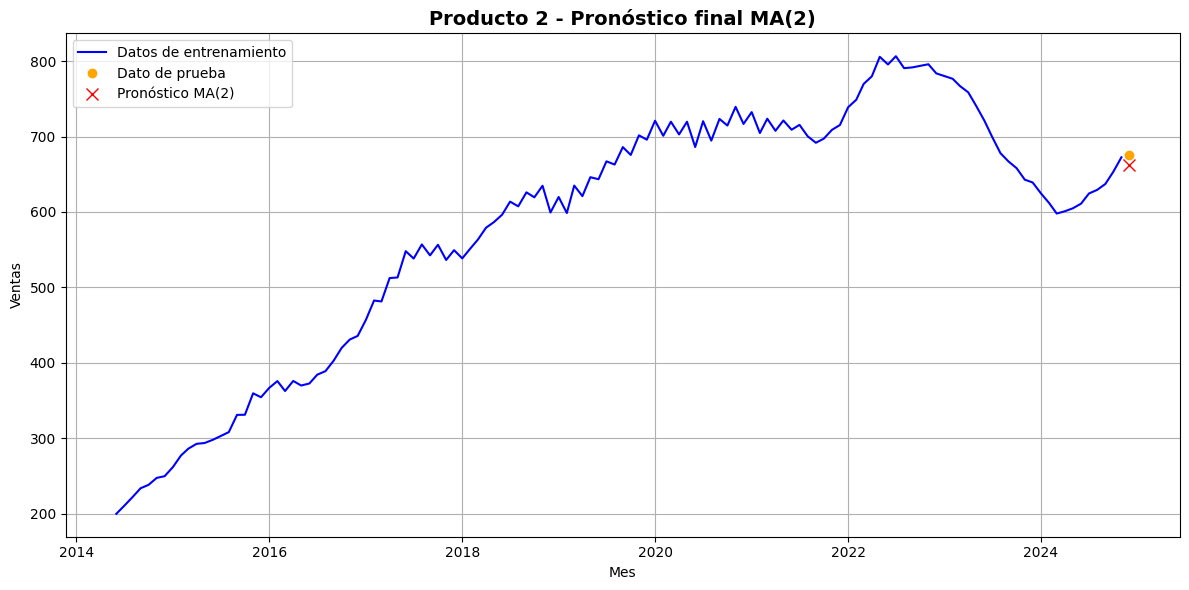


Pronóstico final (MA(2)): 662.84
Dato real:                        676.06
Diferencia pronóstico - real:     -13.22


In [12]:
# =======================================
# 5.1. Modelos de Promedio Móvil (MA)
# =======================================

def fore_ma(datos, w, h=1):
    """
    Pronostica h pasos adelante usando promedio móvil de orden w.
    datos: pandas Series con índice de fechas
    w: orden del promedio móvil
    h: horizonte de pronóstico
    """
    data = datos.copy()
    for _ in range(h):
        sig_fecha = data.index[-1] + pd.DateOffset(months=1)
        data.loc[sig_fecha] = data[-w:].mean()
    return data[-h:]  # devuelve solo los últimos h pronósticos


def evaluate_ma_orders(series, window_size=115, n_iter=12, orders=(2,3,4,5,6), h=1, nombre_serie=""):
    """
    Evalúa varios órdenes de promedio móvil usando ventana móvil.
    Imprime el RMSE de cada iteración en una línea.
    Devuelve un diccionario {orden: RMSE_promedio}.
    """
    rmse_detallado = {w: [] for w in orders}
    total_data = series.copy()

    for i in range(n_iter):
        # Entrenamiento y prueba posicionales
        train = total_data.iloc[i:i + window_size]
        test  = total_data.iloc[i + window_size:i + window_size + h]

        for w in orders:
            pred = fore_ma(train, w, h=h)
            rmse = np.sqrt(mean_squared_error(test, pred))
            rmse_detallado[w].append(rmse)

    # Calcular RMSE promedio por orden
    rmse_promedio = {w: np.mean(rmse_detallado[w]) for w in orders}

    print(f"\n===== RMSE promedio por orden - {nombre_serie} =====")
    for w in orders:
        print(f" MA({w}): {rmse_promedio[w]:.4f}")

    return rmse_promedio


def final_forecast_and_plot(series, best_order, titulo):
    """
    Reentrena con todos los datos menos el último y grafica:
    - Datos de entrenamiento
    - Dato de prueba (última observación)
    - Pronóstico usando MA(best_order)
    """
    # Entrenamiento = todos menos el último
    train_td = series.iloc[:-1]
    test_td  = series.iloc[-1:]

    # Pronóstico final
    forecast = fore_ma(train_td, best_order, h=1)
    f_value = forecast.iloc[0]
    t_value = test_td.iloc[0]

    # Gráfico
    plt.figure(figsize=(12, 6))
    plt.plot(train_td.index, train_td, label="Datos de entrenamiento", color="blue")
    plt.plot(test_td.index, test_td, label="Dato de prueba", color="orange",
             marker="o", markersize=6, linestyle="None")
    plt.plot(test_td.index, [f_value], label=f"Pronóstico MA({best_order})",
             color="red", marker="x", markersize=8, linestyle="None")

    plt.title(titulo + f" - Pronóstico final MA({best_order})", fontsize=14, fontweight="bold")
    plt.xlabel("Mes")
    plt.ylabel("Ventas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Imprimir valores numéricos
    print(f"\nPronóstico final (MA({best_order})): {f_value:.2f}")
    print(f"Dato real:                        {t_value:.2f}")
    print(f"Diferencia pronóstico - real:     {f_value - t_value:.2f}")

    return f_value, t_value, f_value - t_value


# =========================================
# Parámetros del protocolo de ventana móvil
# =========================================

window_size   = 115        # tamaño de la ventana de entrenamiento
n_iteraciones = 12         # número de ventanas
ordenes       = (2,3,4,5,6)
h             = 1          # horizonte = 1 mes

# =========================
# Producto 1
# =========================

serie_p1 = data['producto1']

rmse_p1 = evaluate_ma_orders(serie_p1,
                             window_size=window_size,
                             n_iter=n_iteraciones,
                             orders=ordenes,
                             h=h,
                             nombre_serie="Producto 1")

best_order_p1 = min(rmse_p1, key=rmse_p1.get)
print(f"\n>>> Mejor orden MA para Producto 1: MA({best_order_p1})")

f_p1, t_p1, diff_p1 = final_forecast_and_plot(serie_p1,
                                              best_order_p1,
                                              titulo="Producto 1")


# =========================
# Producto 2
# =========================

serie_p2 = data['producto2']

rmse_p2 = evaluate_ma_orders(serie_p2,
                             window_size=window_size,
                             n_iter=n_iteraciones,
                             orders=ordenes,
                             h=h,
                             nombre_serie="Producto 2")

best_order_p2 = min(rmse_p2, key=rmse_p2.get)
print(f"\n>>> Mejor orden MA para Producto 2: MA({best_order_p2})")

f_p2, t_p2, diff_p2 = final_forecast_and_plot(serie_p2,
                                              best_order_p2,
                                              titulo="Producto 2")


### **5.2. Suavización Exponencial**

#### **Producto 1**

Antes de correr el modelo Holt-Winters, sería valioso hacer uso del algoritmo de optimización bayesiana para hallar los hiperparámetros óptimos que, en el caso de Holt-Winters, son aquellos asociados al error (error), a la tendencia (trend) y a la estacionalidad (seasonal).

In [13]:
# =======================================
# 5.2. Holt-Winters (ETS) con optimización bayesiana - Producto 1
# =======================================

warnings.filterwarnings("ignore")

# Serie a modelar
serie1 = data["producto1"]

def train_and_evaluate_avg_RMSE_p1(error, trend, seasonal, alpha, beta, gamma):
    """
    Entrena un modelo ETS con ventana móvil y devuelve -RMSE promedio
    (negativo porque BayesianOptimization maximiza).
    """

    # Redondeos
    alpha = round(alpha, 2)
    beta  = round(beta, 2)
    gamma = round(gamma, 2)

    error_opts    = ["add", "mul"]
    trend_opts    = ["add", "mul", None]
    seasonal_opts = ["add", "mul", None]

    error_idx    = int(round(error))
    trend_idx    = int(round(trend))
    seasonal_idx = int(round(seasonal))

    # Asegurar que los índices estén en rango
    error_idx    = max(0, min(error_idx,    len(error_opts)    - 1))
    trend_idx    = max(0, min(trend_idx,    len(trend_opts)    - 1))
    seasonal_idx = max(0, min(seasonal_idx, len(seasonal_opts) - 1))

    # Definición de ventanas
    window_size = 115
    n_windows   = len(serie1) - window_size

    rmse_values = []

    for i in range(n_windows):
        train = serie1.iloc[i:i + window_size]
        test  = serie1.iloc[i + window_size:i + window_size + 1]

        # Definir modelo ETS
        try:
            model = ETSModel(
                endog=train,
                error=error_opts[error_idx],
                trend=trend_opts[trend_idx],
                seasonal=seasonal_opts[seasonal_idx],
                seasonal_periods=12
            )

            params = {"smoothing_level": alpha}

            if trend_opts[trend_idx] is not None:
                params["smoothing_trend"] = beta
            if seasonal_opts[seasonal_idx] is not None:
                params["smoothing_seasonal"] = gamma

            result = model.fit_constrained(params)
            forecast = result.forecast(steps=len(test))

            rmse = np.sqrt(mean_squared_error(test, forecast))
            rmse_values.append(rmse)

        except Exception:
            # Penalizar modelos que explotan o son inválidos
            return -1e6

    avg_rmse = np.mean(rmse_values)
    return -avg_rmse  # negativo porque BO maximiza


# Definir los límites para los hiperparámetros
pbounds = {
    "error":   (0, 1),   # 0 → "add", 1 → "mul"
    "trend":   (0, 2),   # 0 → "add", 1 → "mul", 2 → None
    "seasonal":(0, 2),   # 0 → "add", 1 → "mul", 2 → None
    "alpha":   (0.01, 0.99),
    "beta":    (0.01, 0.99),
    "gamma":   (0.01, 0.99),
}

optimizer = BayesianOptimization(
    f=train_and_evaluate_avg_RMSE_p1,
    pbounds=pbounds,
    random_state=1,
    verbose=2
)

optimizer.maximize(init_points=3, n_iter=100)

best_params_p1 = optimizer.max["params"]

# Mapear índices a nombres
error_opts    = ["add", "mul"]
trend_opts    = ["add", "mul", None]
seasonal_opts = ["add", "mul", None]

error_idx    = int(round(best_params_p1["error"]))
trend_idx    = int(round(best_params_p1["trend"]))
seasonal_idx = int(round(best_params_p1["seasonal"]))

error_name    = error_opts[error_idx]
trend_name    = trend_opts[trend_idx]
seasonal_name = seasonal_opts[seasonal_idx]

results_df = pd.DataFrame([{
    "error":    error_name,
    "trend":    trend_name,
    "seasonal": seasonal_name,
    "alpha":    round(best_params_p1["alpha"],  2),
    "beta":     round(best_params_p1["beta"],   2),
    "gamma":    round(best_params_p1["gamma"],  2)
}])

print(results_df)


|   iter    |  target   |   error   |   trend   | seasonal  |   alpha   |   beta    |   gamma   |
-------------------------------------------------------------------------------------------------
| 1         | -7.971683 | 0.4170220 | 1.4406489 | 0.0002287 | 0.3062859 | 0.1538207 | 0.1004918 |
| 2         | -6.550556 | 0.1862602 | 0.6911214 | 0.7935349 | 0.5380403 | 0.4208106 | 0.6815151 |
| 3         | -9.397251 | 0.2044522 | 1.7562348 | 0.0547751 | 0.6670581 | 0.4189587 | 0.5575160 |
| 4         | -9.689919 | 0.6923226 | 0.6365555 | 0.2175526 | 0.6511950 | 0.6227153 | 0.4654342 |
| 5         | -7.714282 | 0.4392159 | 0.6677187 | 1.5312154 | 0.7911056 | 0.9066168 | 0.6397752 |
| 6         | -77.62234 | 0.9635411 | 1.9644268 | 0.5868893 | 0.0569859 | 0.6050203 | 0.4448333 |
| 7         | -8.218462 | 0.0       | 0.9713574 | 0.0813581 | 0.8032336 | 0.1379450 | 0.3737275 |
| 8         | -6.393349 | 0.2489052 | 0.7939249 | 0.7281379 | 0.4964665 | 0.3892900 | 0.6246838 |
| 9         | -7.097

Vemos que, tras la optimización bayesiana, los hiperparámetros óptimos son los siguientes:

- error="add"
- trend="mul"
- seasonal="None"

Corremos entonces el modelo de Holt-Winters fijando ya estos hiperparámetros óptimos.

In [14]:
# ---------------------------------------
# Re-entrenar ETS con los mejores params
# y evaluar con ventana móvil - P1
# ---------------------------------------

warnings.filterwarnings("ignore")

best_error_p1    = "add"
best_trend_p1    = "mul"
best_seasonal_p1 = None
best_alpha_p1    = round(best_params_p1["alpha"], 2)
best_beta_p1     = round(best_params_p1["beta"], 2)
best_gamma_p1    = round(best_params_p1["gamma"], 2)

window_size = 115
n_windows   = len(data) - window_size

rmse_values = []

for i in range(n_windows):
    train = data["producto1"].iloc[i:i + window_size]
    test  = data["producto1"].iloc[i + window_size:i + window_size + 1]

    model = ETSModel(
        endog=train,
        error=best_error_p1,
        trend=best_trend_p1,
        seasonal=best_seasonal_p1
    )

    params = {"smoothing_level": best_alpha_p1}
    if best_trend_p1 is not None:
        params["smoothing_trend"] = best_beta_p1
    # como best_seasonal es None, no ponemos smoothing_seasonal

    result = model.fit_constrained(params)  # fija los parámetros
    point_forecast = result.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, point_forecast))
    rmse_values.append(rmse)

rmse_HW_product1 = np.mean(rmse_values)
print(f"El RMSE promedio sobre todas las ventanas móviles es: {rmse_HW_product1:.4f}")


El RMSE promedio sobre todas las ventanas móviles es: 5.1984


In [15]:
# ---------------------------------------
# Pronóstico final 1 paso adelante (mes 127)
# con ETS óptimo para Producto 1
# ---------------------------------------

warnings.filterwarnings("ignore")

# Datos: meses 1–126 entrenamiento, 127 prueba
train_td = data['producto1'].iloc[:126]
test_td  = data['producto1'].iloc[126:]   # mes 127

# Construir y ajustar el modelo ETS(A, M, N)
ets_model = ETSModel(
    endog=train_td,
    error=best_error_p1,
    trend=best_trend_p1,
    seasonal=best_seasonal_p1
)

# Fijar los parámetros óptimos de suavizamiento encontrados por BO
params = {"smoothing_level": best_alpha_p1}
if best_trend_p1 is not None:
    params["smoothing_trend"] = best_beta_p1
if best_seasonal_p1 is not None:
    params["smoothing_seasonal"] = best_gamma_p1

# Ajustar con parámetros fijados
ets_result = ets_model.fit_constrained(params)

# Pronóstico 1 paso adelante
point_forecast = ets_result.forecast(steps=1)

# Intervalo de predicción al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],
    end=point_forecast.index[-1]
)
conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean

preds_hw_add = pd.concat([limits, conf_forecast], axis=1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']

print(preds_hw_add)
print("\nDato real mes 127:", float(test_td.iloc[0]))

            Point_forecast    lower_95    upper_95
2024-12-01      134.512005  118.121748  149.674865

Dato real mes 127: 141.9908727


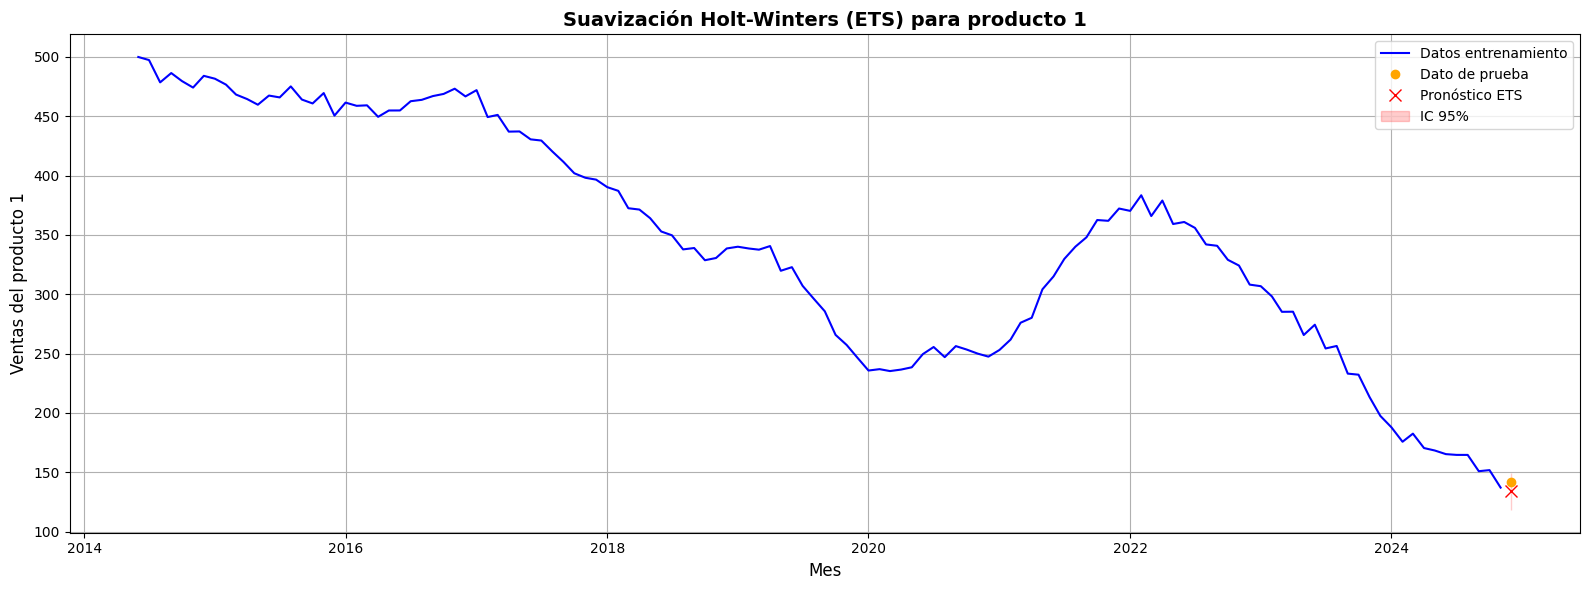

In [16]:
plt.figure(figsize=(16, 6))

# Datos de entrenamiento
plt.plot(train_td.index, train_td,
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_td.index, test_td,
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Punto de pronóstico
plt.plot(point_forecast.index, point_forecast.values,
         label='Pronóstico ETS', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(point_forecast.index,
                 preds_hw_add['lower_95'],
                 preds_hw_add['upper_95'],
                 alpha=0.2, color='red',
                 label='IC 95%')

# Títulos y ejes
plt.title('Suavización Holt-Winters (ETS) para producto 1',
          fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 1', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### **Producto 2**

In [17]:
# =======================================
# 5.2. Holt-Winters (ETS) con BO – Producto 2
# =======================================

warnings.filterwarnings("ignore")

# Serie a modelar
serie2 = data["producto2"]

def train_and_evaluate_avg_RMSE_p2(error, trend, seasonal, alpha, beta, gamma):
    """
    Entrena un modelo ETS con ventana móvil y devuelve -RMSE promedio
    (negativo porque BayesianOptimization maximiza).
    """

    # Redondeos
    alpha = round(alpha, 2)
    beta  = round(beta, 2)
    gamma = round(gamma, 2)

    error_opts    = ["add", "mul"]
    trend_opts    = ["add", "mul", None]
    seasonal_opts = ["add", "mul", None]

    error_idx    = int(round(error))
    trend_idx    = int(round(trend))
    seasonal_idx = int(round(seasonal))

    # Asegurar que los índices estén en rango
    error_idx    = max(0, min(error_idx,    len(error_opts)    - 1))
    trend_idx    = max(0, min(trend_idx,    len(trend_opts)    - 1))
    seasonal_idx = max(0, min(seasonal_idx, len(seasonal_opts) - 1))

    # Definición de ventanas
    window_size = 115
    n_windows   = len(serie2) - window_size

    rmse_values = []

    for i in range(n_windows):
        train = serie2.iloc[i:i + window_size]
        test  = serie2.iloc[i + window_size:i + window_size + 1]

        # Definir modelo ETS
        try:
            model = ETSModel(
                endog=train,
                error=error_opts[error_idx],
                trend=trend_opts[trend_idx],
                seasonal=seasonal_opts[seasonal_idx],
                seasonal_periods=12
            )

            params = {"smoothing_level": alpha}

            if trend_opts[trend_idx] is not None:
                params["smoothing_trend"] = beta
            if seasonal_opts[seasonal_idx] is not None:
                params["smoothing_seasonal"] = gamma

            result = model.fit_constrained(params)
            forecast = result.forecast(steps=len(test))

            rmse = np.sqrt(mean_squared_error(test, forecast))
            rmse_values.append(rmse)

        except Exception:
            # Penalizar modelos que explotan o son inválidos
            return -1e6

    avg_rmse = np.mean(rmse_values)
    return -avg_rmse  # negativo porque BO maximiza


# Definir los límites para los hiperparámetros
pbounds = {
    "error":   (0, 1),   # 0 → "add", 1 → "mul"
    "trend":   (0, 2),   # 0 → "add", 1 → "mul", 2 → None
    "seasonal":(0, 2),   # 0 → "add", 1 → "mul", 2 → None
    "alpha":   (0.01, 0.99),
    "beta":    (0.01, 0.99),
    "gamma":   (0.01, 0.99),
}

optimizer = BayesianOptimization(
    f=train_and_evaluate_avg_RMSE_p2,
    pbounds=pbounds,
    random_state=1,
    verbose=2
)

optimizer.maximize(init_points=3, n_iter=100)

best_params_p2 = optimizer.max["params"]

# Mapear índices a nombres
error_opts    = ["add", "mul"]
trend_opts    = ["add", "mul", None]
seasonal_opts = ["add", "mul", None]

error_idx    = int(round(best_params_p2["error"]))
trend_idx    = int(round(best_params_p2["trend"]))
seasonal_idx = int(round(best_params_p2["seasonal"]))

error_name    = error_opts[error_idx]
trend_name    = trend_opts[trend_idx]
seasonal_name = seasonal_opts[seasonal_idx]

results_df = pd.DataFrame([{
    "error":    error_name,
    "trend":    trend_name,
    "seasonal": seasonal_name,
    "alpha":    round(best_params_p2["alpha"],  2),
    "beta":     round(best_params_p2["beta"],   2),
    "gamma":    round(best_params_p2["gamma"],  2)
}])

print(results_df)


|   iter    |  target   |   error   |   trend   | seasonal  |   alpha   |   beta    |   gamma   |
-------------------------------------------------------------------------------------------------
| 1         | -16.15693 | 0.4170220 | 1.4406489 | 0.0002287 | 0.3062859 | 0.1538207 | 0.1004918 |
| 2         | -9.429471 | 0.1862602 | 0.6911214 | 0.7935349 | 0.5380403 | 0.4208106 | 0.6815151 |
| 3         | -13.42750 | 0.2044522 | 1.7562348 | 0.0547751 | 0.6670581 | 0.4189587 | 0.5575160 |
| 4         | -184.9535 | 0.1252222 | 0.4748810 | 1.0154606 | 0.5967109 | 0.4910967 | 0.8366041 |
| 5         | -6.632199 | 0.4392159 | 0.6677187 | 1.5312154 | 0.7911056 | 0.9066168 | 0.6397752 |
| 6         | -64.36870 | 0.9635411 | 1.9644268 | 0.5868893 | 0.0569859 | 0.6050203 | 0.4448333 |
| 7         | -12.80447 | 0.7538535 | 1.8739956 | 0.0712677 | 0.6801476 | 0.4727935 | 0.6188986 |
| 8         | -13.62121 | 0.9248420 | 0.1513596 | 0.1893492 | 0.2385052 | 0.3912941 | 0.4136667 |
| 9         | -7.463

Vemos que, tras la optimización bayesiana, los hiperparámetros óptimos son los siguientes:

- error="add"
- trend="mul"
- seasonal="None"

Corremos entonces el modelo de Holt-Winters fijando ya estos hiperparámetros óptimos.

In [18]:
# ---------------------------------------
# Re-entrenar ETS con mejores params – P2
# ---------------------------------------

warnings.filterwarnings("ignore")

best_error_p2    = "add"
best_trend_p2   = "mul"
best_seasonal_p2 = None
best_alpha_p2   = round(best_params_p2["alpha"], 2)
best_beta_p2    = round(best_params_p2["beta"], 2)
best_gamma_p2    = round(best_params_p2["gamma"], 2)

window_size = 115
n_windows   = len(data) - window_size

rmse_values = []

for i in range(n_windows):
    train = data["producto2"].iloc[i:i + window_size]
    test  = data["producto2"].iloc[i + window_size:i + window_size + 1]

    model = ETSModel(
        endog=train,
        error=best_error_p2,
        trend=best_trend_p2,
        seasonal=best_seasonal_p2
    )

    params = {"smoothing_level": best_alpha_p2}
    if best_trend_p2 is not None:
        params["smoothing_trend"] = best_beta_p2
    # como best_seasonal es None, no ponemos smoothing_seasonal

    result = model.fit_constrained(params)  # fija los parámetros
    point_forecast = result.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, point_forecast))
    rmse_values.append(rmse)

rmse_HW_product2 = np.mean(rmse_values)
print(f"El RMSE promedio sobre todas las ventanas móviles es: {rmse_HW_product2:.4f}")


El RMSE promedio sobre todas las ventanas móviles es: 6.4352


In [19]:
# ---------------------------------------
# Pronóstico final 1 paso adelante – P2
# ---------------------------------------

warnings.filterwarnings("ignore")

# Datos: meses 1–126 entrenamiento, 127 prueba
train_td = data['producto2'].iloc[:126]
test_td  = data['producto2'].iloc[126:]   # mes 127

# Construir y ajustar el modelo ETS(A, M, N)
ets_model = ETSModel(
    endog=train_td,
    error=best_error_p2,
    trend=best_trend_p2,
    seasonal=best_seasonal_p2
)

# Fijar los parámetros óptimos de suavizamiento encontrados por BO
params = {"smoothing_level": best_alpha_p2}
if best_trend_p2 is not None:
    params["smoothing_trend"] = best_beta_p2
if best_seasonal_p2 is not None:
    params["smoothing_seasonal"] = best_gamma_p2

# Ajustar con parámetros fijados
ets_result = ets_model.fit_constrained(params)

# Pronóstico 1 paso adelante
point_forecast = ets_result.forecast(steps=1)

# Intervalo de predicción al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],
    end=point_forecast.index[-1]
)
conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean

preds_hw_add = pd.concat([limits, conf_forecast], axis=1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']

print(preds_hw_add)
print("\nDato real mes 127:", float(test_td.iloc[0]))


            Point_forecast    lower_95    upper_95
2024-12-01      693.015832  652.672668  732.589445

Dato real mes 127: 676.0580921


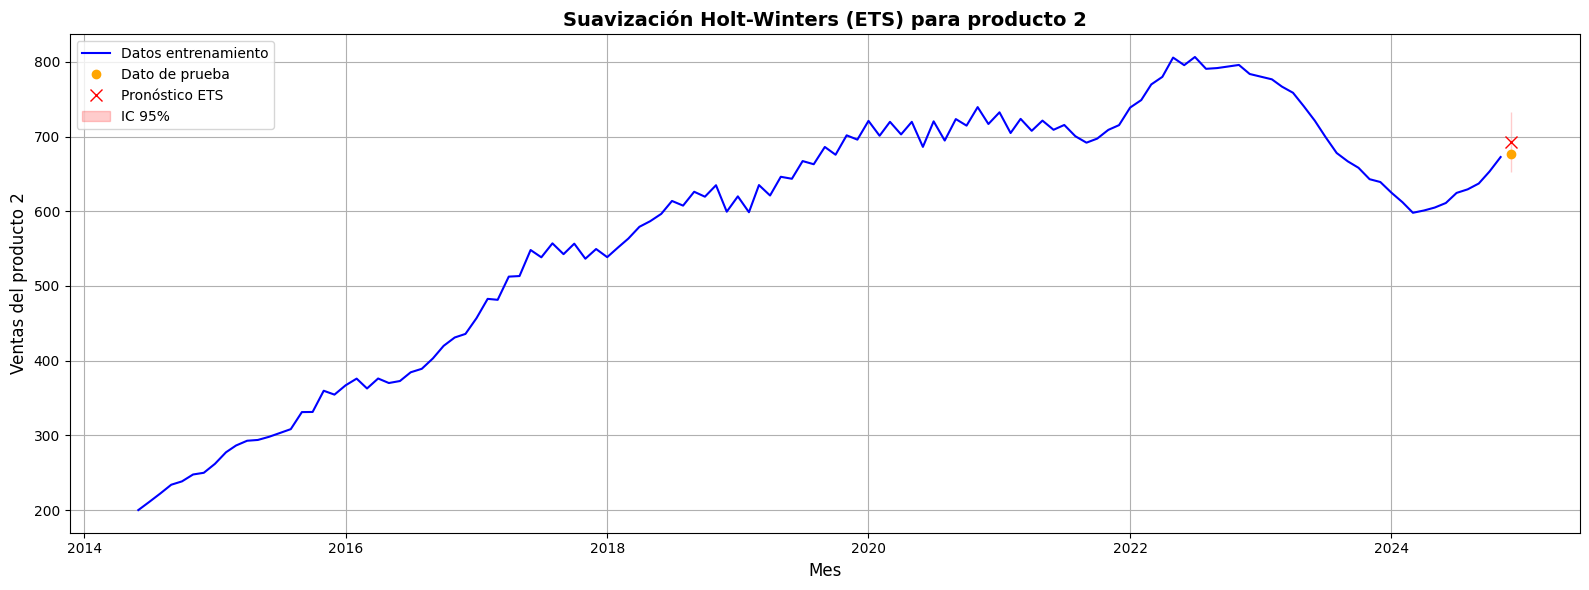

In [20]:
plt.figure(figsize=(16, 6))

# Datos de entrenamiento
plt.plot(train_td.index, train_td,
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_td.index, test_td,
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Punto de pronóstico
plt.plot(point_forecast.index, point_forecast.values,
         label='Pronóstico ETS', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(point_forecast.index,
                 preds_hw_add['lower_95'],
                 preds_hw_add['upper_95'],
                 alpha=0.2, color='red',
                 label='IC 95%')

# Títulos y ejes
plt.title('Suavización Holt-Winters (ETS) para producto 2',
          fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 2', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### **5.3. Regresión - Tendencia lineal / Polinómica + estacionalidad**

#### **Producto 1**

In [24]:
# =======================================
# 5.3. Modelo de regresión
#      (Tendencia lineal/polinómica + estacionalidad)
#      – Producto 1
# =======================================

# Copiamos solo la serie del producto 1
df = data.copy()
df = df[['producto1']].copy()

# Asegurar que producto1 sea numérico
df['producto1'] = pd.to_numeric(df['producto1'], errors='coerce')

# Tendencia (índice de tiempo)
df['t'] = np.arange(1, len(df) + 1).astype(float)

# Crear dummies mensuales como estacionalidad
df['mes'] = df.index.month
dummies_mes = pd.get_dummies(df['mes'], prefix='mes', drop_first=True)

# Asegurar que dummies sean numéricas
dummies_mes = dummies_mes.astype(float)

# Unir al dataframe principal
df = pd.concat([df, dummies_mes], axis=1)


# ---------------------------------------
# Función para entrenar modelo de regresión
# según grado (Producto 1)
# ---------------------------------------
def ajustar_modelo_regresion_p1(train_df, grado, usar_estacionalidad=True):
    """
    Ajusta un modelo de regresión OLS para producto1 con:
      - Tendencia polinómica de grado 'grado'
      - Opcionalmente, dummies estacionales mensuales

    Parámetros
    ----------
    train_df : DataFrame
        Ventana de entrenamiento (subconjunto de df).
    grado : int
        Grado del polinomio en t (1 = lineal, 2 = cuadrático, etc.).
    usar_estacionalidad : bool
        True → incluye dummies de mes; False → solo tendencia.
    """
    X = pd.DataFrame(index=train_df.index)

    # Tendencia polinómica
    for g in range(1, grado + 1):
        X[f"t{g}"] = (train_df['t'] ** g).astype(float)

    # Estacionalidad (dummies mensuales)
    if usar_estacionalidad:
        cols_est = [c for c in train_df.columns if c.startswith('mes_')]
        X[cols_est] = train_df[cols_est].astype(float)

    # Añadir constante
    X = sm.add_constant(X, has_constant='add')

    y = train_df['producto1'].astype(float)

    # Por si quedan NaN en X o y
    mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[mask]
    y_clean = y[mask]

    modelo = sm.OLS(y_clean, X_clean).fit()
    return modelo


# ---------------------------------------
# Evaluación con ventana móvil – Producto 1
# ---------------------------------------
def evaluar_modelo_p1(df, grado, usar_estacionalidad, window_size=115):
    """
    Evalúa un modelo de regresión (grado + estacionalidad)
    mediante ventana móvil y devuelve el RMSE promedio.

    df:                 dataframe completo con producto1, t y dummies
    grado:              grado del polinomio de tendencia
    usar_estacionalidad: True/False
    window_size:        tamaño de la ventana de entrenamiento (115)
    """
    n_windows = len(df) - window_size
    rmse_list = []

    for i in range(n_windows):
        # Definimos ventana de entrenamiento y observación de prueba
        train = df.iloc[i:i + window_size]
        test  = df.iloc[i + window_size:i + window_size + 1]

        # Ajustamos el modelo en la ventana actual
        modelo = ajustar_modelo_regresion_p1(train, grado, usar_estacionalidad)

        # Construir X_test con la misma estructura de X en el entrenamiento
        X_test = pd.DataFrame(index=test.index)

        # Tendencia polinómica en el punto de prueba
        for g in range(1, grado + 1):
            X_test[f"t{g}"] = (test['t'] ** g).astype(float)

        # Estacionalidad, si aplica
        if usar_estacionalidad:
            cols_est = [c for c in df.columns if c.startswith('mes_')]
            X_test[cols_est] = test[cols_est].astype(float).values

        # Añadir constante
        X_test = sm.add_constant(X_test, has_constant='add')
        X_test = X_test.astype(float)

        # Valor real
        y_test = test['producto1'].astype(float)

        # Pronóstico de esta ventana y su RMSE
        pred = modelo.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        rmse_list.append(rmse)

    # RMSE promedio sobre todas las ventanas
    return np.mean(rmse_list)


# --------------------------------------------------------
# Búsqueda del mejor grado de tendencia (1 a 10) y
# comparación con/sin estacionalidad – Producto 1
# --------------------------------------------------------
resultados = []
ordenes = range(1, 11)  # grados 1 a 10
window_size = 115

for grado in ordenes:
    rmse_est    = evaluar_modelo_p1(df, grado,
                                    usar_estacionalidad=True,
                                    window_size=window_size)
    rmse_no_est = evaluar_modelo_p1(df, grado,
                                    usar_estacionalidad=False,
                                    window_size=window_size)

    resultados.append({
        'grado': grado,
        'modelo': f't^{grado} + estacionalidad',
        'rmse1': rmse_est
    })
    resultados.append({
        'grado': grado,
        'modelo': f't^{grado} sin estacionalidad',
        'rmse1': rmse_no_est
    })

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

best_model1 = resultados_df.loc[resultados_df['rmse1'].idxmin()]
print("\n=========================")
print("MEJOR MODELO:")
print(best_model1)
print("=========================")



    grado                   modelo       rmse1
0       1     t^1 + estacionalidad   56.993052
1       1   t^1 sin estacionalidad   54.385861
2       2     t^2 + estacionalidad   90.783762
3       2   t^2 sin estacionalidad   85.498432
4       3     t^3 + estacionalidad   67.797393
5       3   t^3 sin estacionalidad   63.045785
6       4     t^4 + estacionalidad   59.287093
7       4   t^4 sin estacionalidad   56.002158
8       5     t^5 + estacionalidad   91.629383
9       5   t^5 sin estacionalidad   86.760584
10      6     t^6 + estacionalidad   29.850096
11      6   t^6 sin estacionalidad   30.661463
12      7     t^7 + estacionalidad   64.137648
13      7   t^7 sin estacionalidad   58.867803
14      8     t^8 + estacionalidad  157.427760
15      8   t^8 sin estacionalidad  156.479748
16      9     t^9 + estacionalidad  217.889076
17      9   t^9 sin estacionalidad  217.888532
18     10    t^10 + estacionalidad  291.423797
19     10  t^10 sin estacionalidad  291.418164

MEJOR MODELO

In [25]:
# ===========================
# Pronóstico final con el mejor modelo – Producto 1
# ===========================

# 1. Recuperar el mejor modelo según RMSE
best_model = resultados_df.loc[resultados_df['rmse1'].idxmin()]

best_grado = int(best_model['grado'])
best_model_name = best_model['modelo']
usar_estacionalidad = 'sin estacionalidad' not in best_model_name

print("Mejor modelo de regresión seleccionado:")
print(f"  Grado polinómico: {best_grado}")
print(f"  Estacionalidad:   {'Sí' if usar_estacionalidad else 'No'}")
print(f"  RMSE promedio:    {best_model['rmse1']:.4f}")

# 2. Entrenamiento final: meses 1–126, prueba = mes 127
train_df = df.iloc[:126].copy()
test_df  = df.iloc[126:127].copy()   # mes 127

modelo_final = ajustar_modelo_regresion_p1(train_df, best_grado, usar_estacionalidad)

# 3. Construir X_test para el mes 127
X_test = pd.DataFrame(index=test_df.index)
for g in range(1, best_grado + 1):
    X_test[f"t{g}"] = (test_df['t'] ** g).astype(float)

if usar_estacionalidad:
    cols_est = [c for c in df.columns if c.startswith('mes_')]
    X_test[cols_est] = test_df[cols_est].astype(float).values

X_test = sm.add_constant(X_test, has_constant='add')
X_test = X_test.astype(float)

# 4. Pronóstico + intervalo de confianza 95%
pred_obj = modelo_final.get_prediction(X_test)

# Esto suele ser una Series (o array), pero lo convertimos a Series con el índice del test
pred_mean = pd.Series(pred_obj.predicted_mean, index=test_df.index)

# Esto es un numpy.ndarray de shape (n_obs, 2)
pred_int = pred_obj.conf_int(alpha=0.05)    # 95%

# Lo convertimos a Series usando el mismo índice
lower_95 = pd.Series(pred_int[:, 0], index=test_df.index)
upper_95 = pd.Series(pred_int[:, 1], index=test_df.index)

point_forecast = pred_mean

# DataFrame con pronóstico e intervalos
preds_reg = pd.concat([point_forecast, lower_95, upper_95], axis=1)
preds_reg.columns = ['Point_forecast', 'lower_95', 'upper_95']

print("\nPronóstico final modelo de regresión (mes 127):")
print(preds_reg)
print("\nDato real mes 127:", float(test_df['producto1'].iloc[0]))

Mejor modelo de regresión seleccionado:
  Grado polinómico: 6
  Estacionalidad:   Sí
  RMSE promedio:    29.8501

Pronóstico final modelo de regresión (mes 127):
            Point_forecast    lower_95    upper_95
Mes                                               
2024-12-01      141.672192  106.688671  176.655713

Dato real mes 127: 141.9908727


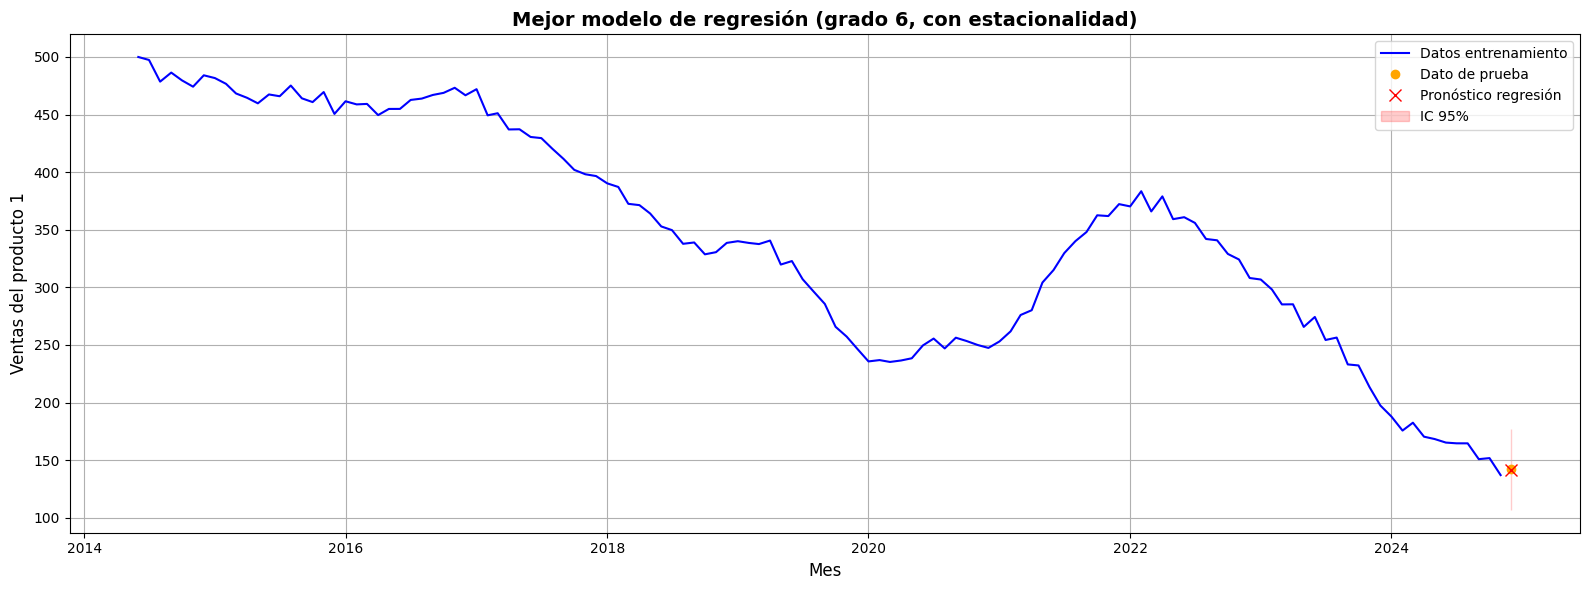

In [26]:
# ===========================
# Gráfica: serie completa + pronóstico + IC
# ===========================
plt.figure(figsize=(16, 6))

# Serie de entrenamiento
plt.plot(train_df.index, train_df['producto1'],
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_df.index, test_df['producto1'],
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Pronóstico
plt.plot(point_forecast.index, point_forecast.values,
         label='Pronóstico regresión', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(point_forecast.index,
                 lower_95.values,
                 upper_95.values,
                 alpha=0.2, color='red',
                 label='IC 95%')

# Etiquetas numéricas opcionales
y_real = float(test_df['producto1'].iloc[0])
y_hat  = float(point_forecast.iloc[0])


plt.title(
    f'Mejor modelo de regresión (grado {best_grado}, '
    f'{"con" if usar_estacionalidad else "sin"} estacionalidad)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 1', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### **Producto 2**

In [29]:
# =======================================
# 5.3. Modelo de regresresión
#      (Tendencia + estacionalidad) – Producto 2
# =======================================

df = data.copy()
df = df[['producto2']].copy()

# Asegurar que producto2 sea numérico
df['producto2'] = pd.to_numeric(df['producto2'], errors='coerce')

# Tendencia temporal
df['t'] = np.arange(1, len(df) + 1).astype(float)

# Crear dummies mensuales para capturar estacionalidad
df['mes'] = df.index.month
dummies_mes = pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float)

# Añadir dummies al dataframe
df = pd.concat([df, dummies_mes], axis=1)


# ---------------------------------------
# Función para entrenar modelo de regresión – Producto 2
# ---------------------------------------
def ajustar_modelo_regresion_p2(train_df, grado, usar_estacionalidad=True):
    """
    Ajusta un modelo OLS para producto2 con:
      - Tendencia polinómica de grado 'grado'
      - Estacionalidad mensual opcional (dummies)
    """
    X = pd.DataFrame(index=train_df.index)

    # Tendencia polinómica
    for g in range(1, grado + 1):
        X[f"t{g}"] = (train_df['t'] ** g).astype(float)

    # Estacionalidad mediante dummies mensuales
    if usar_estacionalidad:
        cols_est = [c for c in train_df.columns if c.startswith('mes_')]
        X[cols_est] = train_df[cols_est].astype(float)

    # Añadir constante
    X = sm.add_constant(X, has_constant='add')

    y = train_df['producto2'].astype(float)

    # Limpieza por si hay NaN
    mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[mask]
    y_clean = y[mask]

    modelo = sm.OLS(y_clean, X_clean).fit()
    return modelo


# ---------------------------------------
# Evaluación con ventana móvil – Producto 2
# ---------------------------------------
def evaluar_modelo_p2(df, grado, usar_estacionalidad, window_size=115):
    """
    Evalúa un modelo de regresión con ventana móvil y devuelve RMSE promedio.
    """
    n_windows = len(df) - window_size
    rmse_list = []

    for i in range(n_windows):
        # Definir ventana de entrenamiento y prueba
        train = df.iloc[i:i + window_size]
        test  = df.iloc[i + window_size:i + window_size + 1]

        modelo = ajustar_modelo_regresion_p2(train, grado, usar_estacionalidad)

        # Construcción del vector de características para el mes de prueba
        X_test = pd.DataFrame(index=test.index)

        for g in range(1, grado + 1):
            X_test[f"t{g}"] = (test['t'] ** g).astype(float)

        if usar_estacionalidad:
            cols_est = [c for c in df.columns if c.startswith('mes_')]
            X_test[cols_est] = test[cols_est].astype(float).values

        # Añadir constante
        X_test = sm.add_constant(X_test, has_constant='add').astype(float)

        y_test = test['producto2'].astype(float)

        # RMSE de la iteración
        pred = modelo.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        rmse_list.append(rmse)

    # Promedio final del modelo
    return np.mean(rmse_list)


# --------------------------------------------------------
# Búsqueda del mejor modelo (grados 1–10, con/sin estacionalidad)
# --------------------------------------------------------

resultados = []
ordenes = range(1, 11)
window_size = 115

for grado in ordenes:
    rmse_est    = evaluar_modelo_p2(df, grado, usar_estacionalidad=True,  window_size=window_size)
    rmse_no_est = evaluar_modelo_p2(df, grado, usar_estacionalidad=False, window_size=window_size)

    resultados.append({'grado': grado, 'modelo': f't^{grado} + estacionalidad',   'rmse2': rmse_est})
    resultados.append({'grado': grado, 'modelo': f't^{grado} sin estacionalidad', 'rmse2': rmse_no_est})

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

# Identificar el mejor (menor RMSE)
best_model2 = resultados_df.loc[resultados_df['rmse2'].idxmin()]

print("\n=========================")
print("MEJOR MODELO:")
print(best_model2)
print("=========================")


    grado                   modelo       rmse2
0       1     t^1 + estacionalidad  212.479366
1       1   t^1 sin estacionalidad  200.096756
2       2     t^2 + estacionalidad   61.011594
3       2   t^2 sin estacionalidad   57.370431
4       3     t^3 + estacionalidad   52.230776
5       3   t^3 sin estacionalidad   49.042525
6       4     t^4 + estacionalidad   57.998069
7       4   t^4 sin estacionalidad   54.643860
8       5     t^5 + estacionalidad   73.968741
9       5   t^5 sin estacionalidad   71.468399
10      6     t^6 + estacionalidad   72.012167
11      6   t^6 sin estacionalidad   69.451534
12      7     t^7 + estacionalidad   37.315483
13      7   t^7 sin estacionalidad   37.298773
14      8     t^8 + estacionalidad   42.932273
15      8   t^8 sin estacionalidad   42.349906
16      9     t^9 + estacionalidad  189.424563
17      9   t^9 sin estacionalidad  189.424143
18     10    t^10 + estacionalidad  236.239874
19     10  t^10 sin estacionalidad  236.235044

MEJOR MODELO

In [30]:
# ===========================
# Pronóstico final con el mejor modelo – Producto 2
# ===========================

# 1. Recuperar el mejor modelo según RMSE
best_model = resultados_df.loc[resultados_df['rmse2'].idxmin()]

best_grado = int(best_model['grado'])
best_model_name = best_model['modelo']
usar_estacionalidad = 'sin estacionalidad' not in best_model_name

print("Mejor modelo de regresión seleccionado:")
print(f"  Grado polinómico: {best_grado}")
print(f"  Estacionalidad:   {'Sí' if usar_estacionalidad else 'No'}")
print(f"  RMSE promedio:    {best_model['rmse2']:.4f}")

# 2. Entrenamiento final: meses 1–126, prueba = mes 127
train_df = df.iloc[:126].copy()
test_df  = df.iloc[126:127].copy()   # mes 127

modelo_final = ajustar_modelo_regresion_p2(train_df, best_grado, usar_estacionalidad)

# 3. Construir X_test para el mes 127
X_test = pd.DataFrame(index=test_df.index)
for g in range(1, best_grado + 1):
    X_test[f"t{g}"] = (test_df['t'] ** g).astype(float)

if usar_estacionalidad:
    cols_est = [c for c in df.columns if c.startswith('mes_')]
    X_test[cols_est] = test_df[cols_est].astype(float).values

X_test = sm.add_constant(X_test, has_constant='add')
X_test = X_test.astype(float)

# 4. Pronóstico + intervalo de confianza 95%
pred_obj = modelo_final.get_prediction(X_test)

# Esto suele ser una Series (o array), pero lo convertimos a Series con el índice del test
pred_mean = pd.Series(pred_obj.predicted_mean, index=test_df.index)

# Esto es un numpy.ndarray de shape (n_obs, 2)
pred_int = pred_obj.conf_int(alpha=0.05)    # 95%

# Lo convertimos a Series usando el mismo índice
lower_95 = pd.Series(pred_int[:, 0], index=test_df.index)
upper_95 = pd.Series(pred_int[:, 1], index=test_df.index)

point_forecast = pred_mean

# DataFrame con pronóstico e intervalos
preds_reg = pd.concat([point_forecast, lower_95, upper_95], axis=1)
preds_reg.columns = ['Point_forecast', 'lower_95', 'upper_95']

print("\nPronóstico final modelo de regresión (mes 127):")
print(preds_reg)
print("\nDato real mes 127:", float(test_df['producto2'].iloc[0]))

Mejor modelo de regresión seleccionado:
  Grado polinómico: 7
  Estacionalidad:   No
  RMSE promedio:    37.2988

Pronóstico final modelo de regresión (mes 127):
            Point_forecast    lower_95    upper_95
Mes                                               
2024-12-01      716.300686  672.936277  759.665095

Dato real mes 127: 676.0580921


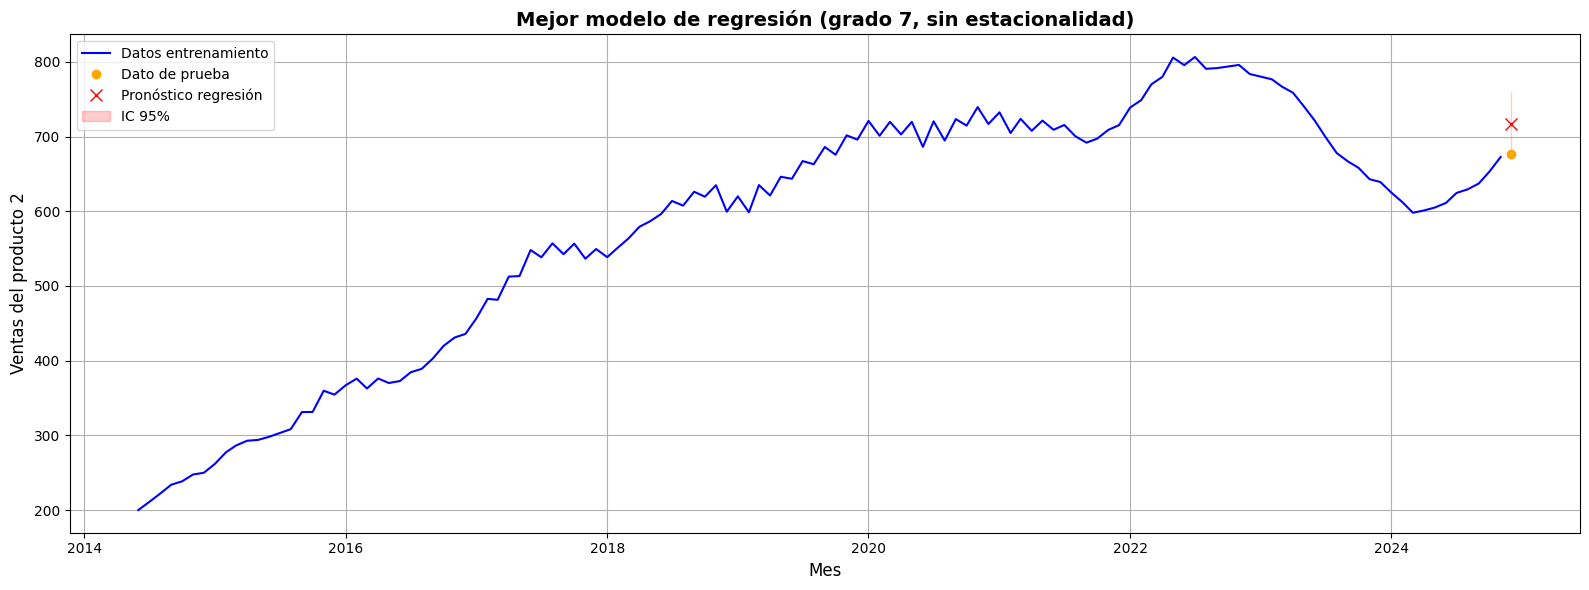

In [31]:
# ===========================
# Gráfica: serie completa + pronóstico + IC
# ===========================
plt.figure(figsize=(16, 6))

# Serie de entrenamiento
plt.plot(train_df.index, train_df['producto2'],
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_df.index, test_df['producto2'],
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Pronóstico
plt.plot(point_forecast.index, point_forecast.values,
         label='Pronóstico regresión', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(point_forecast.index,
                 lower_95.values,
                 upper_95.values,
                 alpha=0.2, color='red',
                 label='IC 95%')

# Etiquetas numéricas opcionales
y_real = float(test_df['producto2'].iloc[0])
y_hat  = float(point_forecast.iloc[0])


plt.title(
    f'Mejor modelo de regresión (grado {best_grado}, '
    f'{"con" if usar_estacionalidad else "sin"} estacionalidad)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 2', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### **5.4. ARIMA**

#### **Producto 1**

In [32]:
# =======================================
# 5.7. Modelos ARIMA – Producto 1
# =======================================

# Extraer los valores de la columna "product1"
ventas = data['producto1'].values

# Grid de órdenes ARIMA (p, d, q) a evaluar
lista_ordenes_probar = [
    (1, 1, 1), (1, 1, 2), (1, 1, 3),
    (1, 2, 1), (1, 2, 2), (1, 2, 3),
    (1, 3, 1), (1, 3, 2), (1, 3, 3),
    (2, 1, 1), (2, 1, 2), (2, 1, 3),
    (2, 2, 1), (2, 2, 2), (2, 2, 3),
    (2, 3, 1), (2, 3, 2), (2, 3, 3),
    (3, 1, 1), (3, 1, 2), (3, 1, 3),
    (3, 2, 1), (3, 2, 2), (3, 2, 3),
    (3, 3, 1), (3, 3, 2), (3, 3, 3)
]

# Parámetros del protocolo de ventana móvil
n_total = len(ventas)
window_size = 115
n_windows = n_total - window_size   # 127 - 115 = 12

resultados_rmse_promedio = []

# Evaluación ARIMA con ventana móvil

for orden in lista_ordenes_probar:
    rmses_ventanas = []

    for i in range(n_windows):
        inicio = i
        fin = i + window_size   # [inicio, fin) → 115 obs

        train = ventas[inicio:fin]       # 115 datos
        test  = ventas[fin:fin+1]        # siguiente dato fuera de la ventana

        try:
            model = ARIMA(train, order=orden)
            model_fit = model.fit()
            prediccion = model_fit.forecast(steps=1)
            rmse = np.sqrt(mean_squared_error(test, prediccion))
            rmses_ventanas.append(rmse)
        except Exception:
            rmses_ventanas.append(np.nan)

    rmse_promedio = np.nanmean(rmses_ventanas)
    resultados_rmse_promedio.append((orden, rmse_promedio))

df_resultados = pd.DataFrame(resultados_rmse_promedio,
                             columns=['Orden ARIMA', 'RMSE Promedio1'])
# Mostrar los resultados en forma de tabla
print(df_resultados.to_string(index=False))

Orden ARIMA  RMSE Promedio1
  (1, 1, 1)        6.479314
  (1, 1, 2)        7.515175
  (1, 1, 3)        6.414891
  (1, 2, 1)        5.598278
  (1, 2, 2)        5.970089
  (1, 2, 3)        5.612437
  (1, 3, 1)        6.398590
  (1, 3, 2)        5.675568
  (1, 3, 3)        6.039895
  (2, 1, 1)        4.793994
  (2, 1, 2)        5.394982
  (2, 1, 3)        5.577888
  (2, 2, 1)        5.654280
  (2, 2, 2)        5.936980
  (2, 2, 3)        5.996537
  (2, 3, 1)        5.662614
  (2, 3, 2)        5.709951
  (2, 3, 3)        5.679413
  (3, 1, 1)        4.813512
  (3, 1, 2)        4.766611
  (3, 1, 3)        5.356899
  (3, 2, 1)        5.651006
  (3, 2, 2)        6.507273
  (3, 2, 3)        5.845238
  (3, 3, 1)        5.701463
  (3, 3, 2)        5.780521
  (3, 3, 3)        5.940759


In [33]:
# ==========================
# Elegir el mejor modelo ARIMA según RMSE promedio
# ==========================

mejor_fila = df_resultados.loc[df_resultados['RMSE Promedio1'].idxmin()]
best_order1 = mejor_fila['Orden ARIMA']
rmse_arima_p1 = mejor_fila['RMSE Promedio1']

print("\n=========================")
print("MEJOR MODELO ARIMA:")
print(f"  Orden: {best_order1}")
print(f"  RMSE promedio (ventana móvil): {rmse_arima_p1:.4f}")
print("=========================\n")



MEJOR MODELO ARIMA:
  Orden: (3, 1, 2)
  RMSE promedio (ventana móvil): 4.7666



En este caso, el modelo ARIMA que se presenta el menor RMSE es el que se tiene el orden (3,1,2), el cual, presenta un RMSE igual a 4.7666.

Pronóstico ARIMA para el mes 127:
            Point_forecast    lower_95    upper_95
2024-12-01      136.411915  122.184747  150.639083

Dato real mes 127: 141.9908727


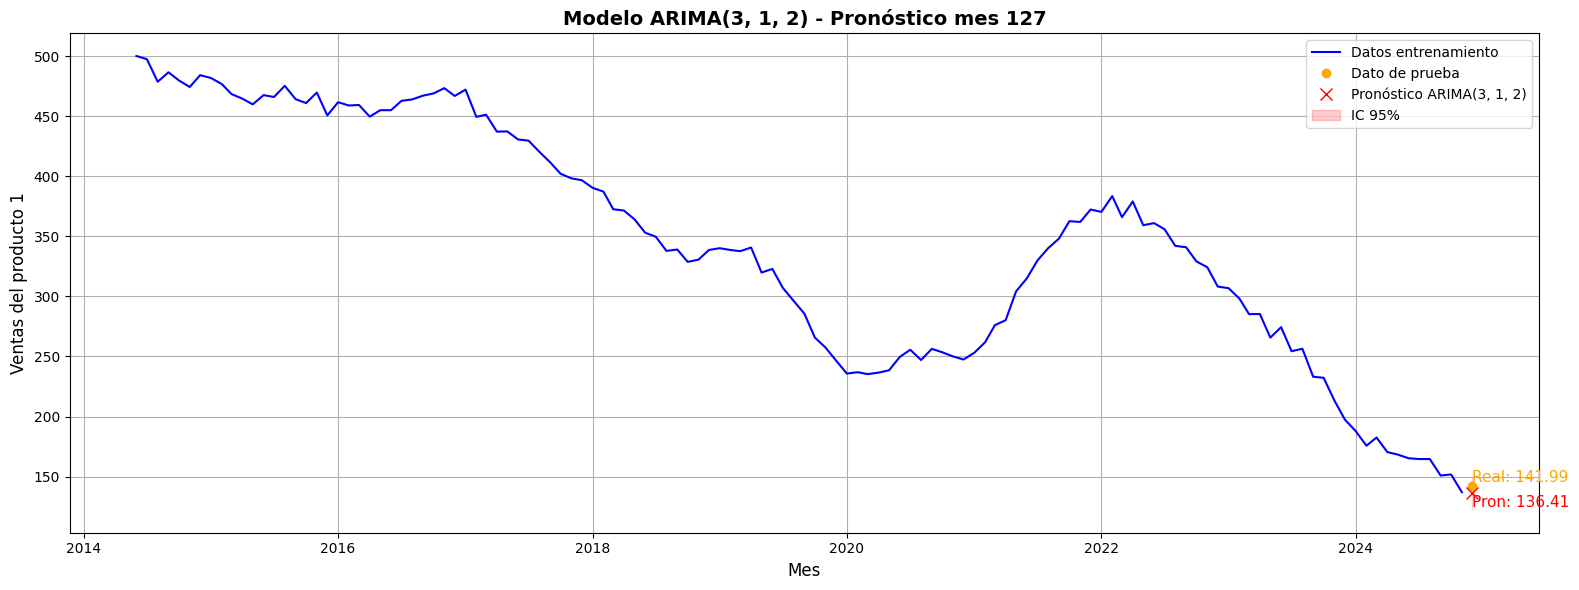

In [34]:
# --------------------------------------------------------
# ARIMA final con datos 1–126 y pronóstico mes 127 – P1
# --------------------------------------------------------

# Usamos la serie con índice de fechas para que la gráfica quede bien
serie = data['producto1']

train_arima = serie.iloc[:126]   # meses 1–126
test_arima  = serie.iloc[126:]   # mes 127 (dato real)

modelo_final_arima = ARIMA(train_arima, order=best_order1)
resultado_final_arima = modelo_final_arima.fit()

# Pronóstico 1 paso adelante con IC 95%
forecast_res = resultado_final_arima.get_forecast(steps=1)
pred_mean = forecast_res.predicted_mean        # Serie con índice del paso pronosticado
conf_int = forecast_res.conf_int(alpha=0.05)   # DataFrame con columnas ['lower y', 'upper y']

# Armamos DataFrame para claridad
preds_arima = pd.concat(
    [pred_mean, conf_int.iloc[:, 0], conf_int.iloc[:, 1]],
    axis=1
)
preds_arima.columns = ['Point_forecast', 'lower_95', 'upper_95']

print("Pronóstico ARIMA para el mes 127:")
print(preds_arima)
print("\nDato real mes 127:", float(test_arima.iloc[0]))

# ==========================
# Gráfica: serie completa + pronóstico + IC
# ==========================
plt.figure(figsize=(16, 6))

# Datos de entrenamiento
plt.plot(train_arima.index, train_arima,
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_arima.index, test_arima,
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Pronóstico
plt.plot(pred_mean.index, pred_mean.values,
         label=f'Pronóstico ARIMA{best_order1}', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(pred_mean.index,
                 preds_arima['lower_95'],
                 preds_arima['upper_95'],
                 alpha=0.2, color='red',
                 label='IC 95%')

# Etiquetas numéricas opcionales
y_real = float(test_arima.iloc[0])
y_hat  = float(pred_mean.iloc[0])

plt.text(test_arima.index[0], y_real + 0.01*abs(y_real),
         f'Real: {y_real:.2f}', color='orange',
         fontsize=11, ha='left', va='bottom')

plt.text(pred_mean.index[0], y_hat - 0.01*abs(y_hat),
         f'Pron: {y_hat:.2f}', color='red',
         fontsize=11, ha='left', va='top')

# Títulos y ejes
plt.title(f'Modelo ARIMA{best_order1} - Pronóstico mes 127',
          fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 1', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### **Producto 2**

In [35]:
# =======================================
# 5.7. Modelos ARIMA – Producto 2
# =======================================

# Extraer los valores de la columna "product2"
ventas = data['producto2'].values

# Lista de órdenes ARIMA a probar
lista_ordenes_probar = [
    (1, 1, 1), (1, 1, 2), (1, 1, 3),
    (1, 2, 1), (1, 2, 2), (1, 2, 3),
    (1, 3, 1), (1, 3, 2), (1, 3, 3),
    (2, 1, 1), (2, 1, 2), (2, 1, 3),
    (2, 2, 1), (2, 2, 2), (2, 2, 3),
    (2, 3, 1), (2, 3, 2), (2, 3, 3),
    (3, 1, 1), (3, 1, 2), (3, 1, 3),
    (3, 2, 1), (3, 2, 2), (3, 2, 3),
    (3, 3, 1), (3, 3, 2), (3, 3, 3)
]

# Parámetros del protocolo de ventana móvil
n_total = len(ventas)
window_size = 115
n_windows = n_total - window_size   # 127 - 115 = 12

resultados_rmse_promedio = []

# Evaluación ARIMA con ventana móvil

for orden in lista_ordenes_probar:
    rmses_ventanas = []

    for i in range(n_windows):
        inicio = i
        fin = i + window_size   # [inicio, fin) → 115 obs

        train = ventas[inicio:fin]       # 115 datos
        test  = ventas[fin:fin+1]        # siguiente dato fuera de la ventana

        try:
            model = ARIMA(train, order=orden)
            model_fit = model.fit()
            prediccion = model_fit.forecast(steps=1)
            rmse = np.sqrt(mean_squared_error(test, prediccion))
            rmses_ventanas.append(rmse)
        except Exception:
            rmses_ventanas.append(np.nan)

    rmse_promedio = np.nanmean(rmses_ventanas)
    resultados_rmse_promedio.append((orden, rmse_promedio))

df_resultados = pd.DataFrame(resultados_rmse_promedio,
                             columns=['Orden ARIMA', 'RMSE Promedio2'])

# Mostrar los resultados en forma de tabla
print(df_resultados.to_string(index=False))

Orden ARIMA  RMSE Promedio2
  (1, 1, 1)       10.887286
  (1, 1, 2)        8.741821
  (1, 1, 3)        8.681842
  (1, 2, 1)        8.135553
  (1, 2, 2)        8.115463
  (1, 2, 3)        8.205281
  (1, 3, 1)        7.987062
  (1, 3, 2)        8.143694
  (1, 3, 3)        8.142433
  (2, 1, 1)        8.110534
  (2, 1, 2)        8.159486
  (2, 1, 3)        7.985189
  (2, 2, 1)        8.162401
  (2, 2, 2)        8.311347
  (2, 2, 3)        8.626570
  (2, 3, 1)        8.124311
  (2, 3, 2)        8.170747
  (2, 3, 3)        8.075207
  (3, 1, 1)        8.040453
  (3, 1, 2)        8.102311
  (3, 1, 3)        7.970287
  (3, 2, 1)        8.308474
  (3, 2, 2)        8.045214
  (3, 2, 3)        8.677666
  (3, 3, 1)        8.122336
  (3, 3, 2)        8.057206
  (3, 3, 3)        7.770159


In [36]:
# ==========================
# Elegir el mejor modelo ARIMA según RMSE promedio
# ==========================
mejor_fila2 = df_resultados.loc[df_resultados['RMSE Promedio2'].idxmin()]
best_order2 = mejor_fila2['Orden ARIMA']
rmse_arima_p2 = mejor_fila2['RMSE Promedio2']

print("\n=========================")
print("MEJOR MODELO ARIMA:")
print(f"  Orden: {best_order2}")
print(f"  RMSE promedio (ventana móvil): {rmse_arima_p2:.4f}")
print("=========================\n")


MEJOR MODELO ARIMA:
  Orden: (3, 3, 3)
  RMSE promedio (ventana móvil): 7.7702



En este caso, el modelo ARIMA que se presenta el menor RMSE es el que se tiene el orden (3,3,3), el cual, presenta un RMSE igual a 7.7702.

Pronóstico ARIMA para el mes 127:
            Point_forecast   lower_95    upper_95
2024-12-01      686.780936  667.24316  706.318713

Dato real mes 127: 676.0580921


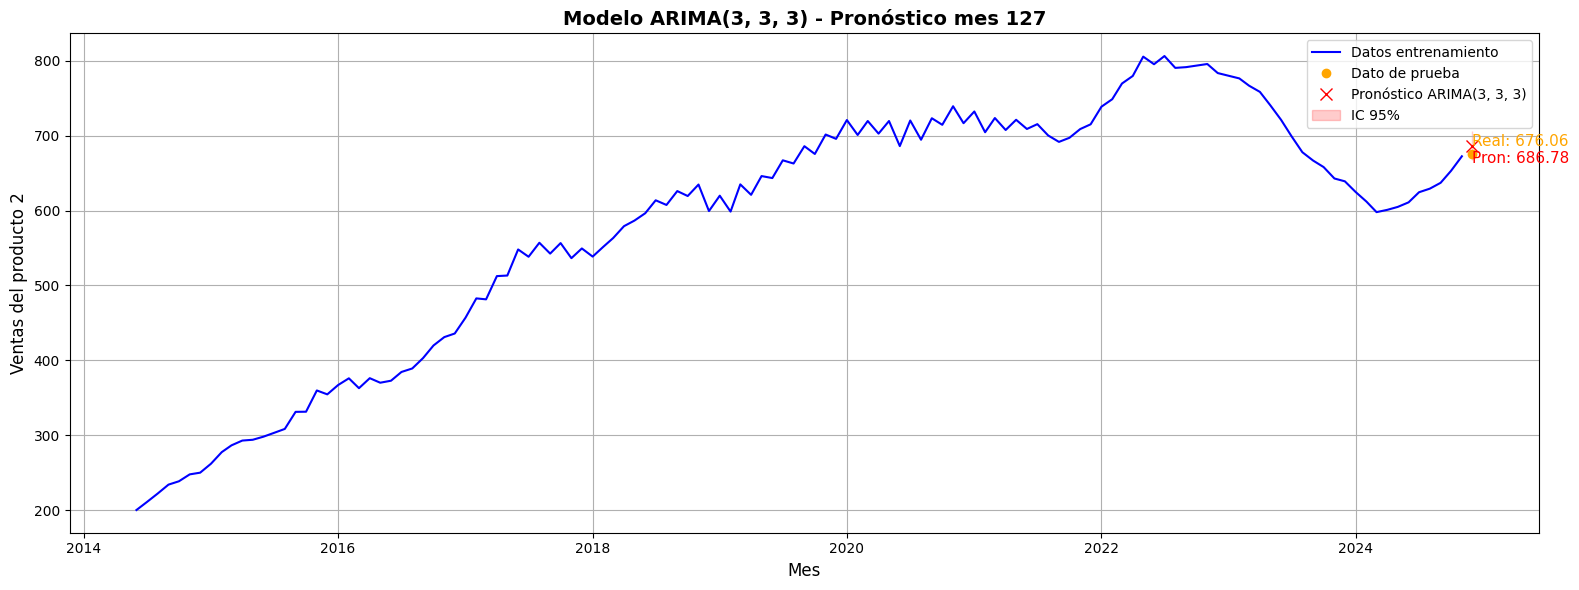

In [37]:
# ==========================
# Ajustar ARIMA final con datos 1–126 y pronosticar 127 – P2
# ==========================
# Usamos la serie con índice de fechas para que la gráfica quede bien
serie = data['producto2']

train_arima = serie.iloc[:126]   # meses 1–126
test_arima  = serie.iloc[126:]   # mes 127 (dato real)

modelo_final_arima = ARIMA(train_arima, order=best_order2)
resultado_final_arima = modelo_final_arima.fit()

# Pronóstico 1 paso adelante con IC 95%
forecast_res = resultado_final_arima.get_forecast(steps=1)
pred_mean = forecast_res.predicted_mean        # Serie con índice del paso pronosticado
conf_int = forecast_res.conf_int(alpha=0.05)   # DataFrame con columnas ['lower y', 'upper y']

# Armamos DataFrame para claridad
preds_arima = pd.concat(
    [pred_mean, conf_int.iloc[:, 0], conf_int.iloc[:, 1]],
    axis=1
)
preds_arima.columns = ['Point_forecast', 'lower_95', 'upper_95']

print("Pronóstico ARIMA para el mes 127:")
print(preds_arima)
print("\nDato real mes 127:", float(test_arima.iloc[0]))

# ==========================
# Gráfica: serie completa + pronóstico + IC
# ==========================
plt.figure(figsize=(16, 6))

# Datos de entrenamiento
plt.plot(train_arima.index, train_arima,
         label='Datos entrenamiento', color='blue')

# Dato de prueba (mes 127)
plt.plot(test_arima.index, test_arima,
         label='Dato de prueba', color='orange',
         marker='o', markersize=6, linestyle='None')

# Pronóstico
plt.plot(pred_mean.index, pred_mean.values,
         label=f'Pronóstico ARIMA{best_order2}', color='red',
         marker='x', markersize=8, linestyle='None')

# Banda de confianza 95 %
plt.fill_between(pred_mean.index,
                 preds_arima['lower_95'],
                 preds_arima['upper_95'],
                 alpha=0.2, color='red',
                 label='IC 95%')

# Etiquetas numéricas opcionales
y_real = float(test_arima.iloc[0])
y_hat  = float(pred_mean.iloc[0])

plt.text(test_arima.index[0], y_real + 0.01*abs(y_real),
         f'Real: {y_real:.2f}', color='orange',
         fontsize=11, ha='left', va='bottom')

plt.text(pred_mean.index[0], y_hat - 0.01*abs(y_hat),
         f'Pron: {y_hat:.2f}', color='red',
         fontsize=11, ha='left', va='top')

# Títulos y ejes
plt.title(f'Modelo ARIMA{best_order2} - Pronóstico mes 127',
          fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas del producto 2', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### **5.5. Prophet**

In [38]:
# =======================================
# 5.8. Prophet – Optimización con Optuna
# =======================================

# Se silencian mensajes de cmdstan y Prophet para un output más limpio
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").disabled = True

#### **Producto 1**

In [39]:
# =========================
# Prophet - Producto 1
# =========================

serie_p1 = data["producto1"]

def objective_prophet_p1(trial):

    """
    Función objetivo para Optuna (Producto 1).
    Optimiza hiperparámetros clave de Prophet bajo
    el protocolo de ventana móvil:

      - changepoint_prior_scale
      - seasonality_prior_scale
      - seasonality_mode (aditiva / multiplicativa)

    Retorna el RMSE promedio sobre las 12 ventanas móviles.
    """

    changepoint_prior_scale = trial.suggest_float(
        "changepoint_prior_scale", 0.001, 0.5, log=True
    )
    seasonality_prior_scale = trial.suggest_float(
        "seasonality_prior_scale", 0.01, 10.0, log=True
    )
    seasonality_mode = trial.suggest_categorical(
        "seasonality_mode", ["additive", "multiplicative"]
    )

    window_size = 115
    n_windows = len(serie_p1) - window_size
    rmse_list = []

    for i in range(n_windows):
        train = serie_p1.iloc[i:i + window_size]
        test  = serie_p1.iloc[i + window_size:i + window_size + 1]

        # Prophet necesita columnas ds, y
        df_train = train.reset_index()
        df_train.columns = ["ds", "y"]

        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode=seasonality_mode,
            changepoint_prior_scale=changepoint_prior_scale,
            seasonality_prior_scale=seasonality_prior_scale
        )

        try:
            m.fit(df_train)
            future = m.make_future_dataframe(periods=1, freq="MS")
            forecast = m.predict(future)
            yhat = forecast["yhat"].iloc[-1]

            rmse = np.sqrt(mean_squared_error(test.values, [yhat]))
            rmse_list.append(rmse)
        except Exception:
            # Penaliza configuraciones que fallen
            return 1e6

    return np.mean(rmse_list)

In [40]:
# Optuna ejecuta 30 combinaciones

sampler_p1 = optuna.samplers.TPESampler(seed=123)
study_p1 = optuna.create_study(direction="minimize", sampler=sampler_p1)
study_p1.optimize(objective_prophet_p1, n_trials=30, show_progress_bar=True)

print("Mejores hiperparámetros Prophet p1:")
print(study_p1.best_params)
print("RMSE promedio Prophet p1:", study_p1.best_value)


[I 2025-12-05 04:47:22,854] A new study created in memory with name: no-name-7f055f5d-188e-4f9f-b12f-59110a912986


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-05 04:47:26,595] Trial 0 finished with value: 35.246995489617255 and parameters: {'changepoint_prior_scale': 0.07581400522768209, 'seasonality_prior_scale': 0.07218018732952583, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 35.246995489617255.
[I 2025-12-05 04:47:28,246] Trial 1 finished with value: 14.044739340721549 and parameters: {'changepoint_prior_scale': 0.08746316087971377, 'seasonality_prior_scale': 0.18591711878786357, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:29,367] Trial 2 finished with value: 54.335657326050956 and parameters: {'changepoint_prior_scale': 0.019861899325201982, 'seasonality_prior_scale': 0.1500902754323389, 'seasonality_mode': 'multiplicative'}. Best is trial 1 with value: 14.044739340721549.


[I 2025-12-05 04:47:30,484] Trial 3 finished with value: 52.009297964566564 and parameters: {'changepoint_prior_scale': 0.0152648778399198, 'seasonality_prior_scale': 0.015101973012087265, 'seasonality_mode': 'multiplicative'}. Best is trial 1 with value: 14.044739340721549.


[I 2025-12-05 04:47:33,874] Trial 4 finished with value: 53.86268333634079 and parameters: {'changepoint_prior_scale': 0.003108420085359684, 'seasonality_prior_scale': 0.03360123720029355, 'seasonality_mode': 'multiplicative'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:34,988] Trial 5 finished with value: 82.39489460697376 and parameters: {'changepoint_prior_scale': 0.05155005795238134, 'seasonality_prior_scale': 3.534234664650462, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:36,351] Trial 6 finished with value: 14.15858196924998 and parameters: {'changepoint_prior_scale': 0.08909493583318427, 'seasonality_prior_scale': 0.0930843652400799, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:37,621] Trial 7 finished with value: 37.794583990761 and parameters: {'changepoint_prior_scale': 0.006204765906220318, 'seasonality_prior_scale': 0.7814989008992038, 'se

[I 2025-12-05 04:47:53,108] Trial 16 finished with value: 14.174032203985803 and parameters: {'changepoint_prior_scale': 0.1194575900225309, 'seasonality_prior_scale': 0.011174598119937635, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.


[I 2025-12-05 04:47:56,931] Trial 17 finished with value: 56.06825674961369 and parameters: {'changepoint_prior_scale': 0.0010252283224528875, 'seasonality_prior_scale': 0.43245466791456366, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:58,062] Trial 18 finished with value: 67.40866597073672 and parameters: {'changepoint_prior_scale': 0.03301492457629169, 'seasonality_prior_scale': 1.7322939731178855, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:47:59,969] Trial 19 finished with value: 15.019659639065031 and parameters: {'changepoint_prior_scale': 0.36464561454579714, 'seasonality_prior_scale': 0.14024368238177132, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 14.044739340721549.
[I 2025-12-05 04:48:01,398] Trial 20 finished with value: 13.887756508558788 and parameters: {'changepoint_prior_scale': 0.0882649145756549, 'seasonality_prior_scale': 8.531806116673016, '

In [41]:
# =========================
# Pronóstico final (mes 127) – Producto 1
# =========================

best_params_prophet_p1 = study_p1.best_params

train_p1 = serie_p1.iloc[:126]
test_p1  = serie_p1.iloc[126:]

df_train_p1 = train_p1.reset_index()
df_train_p1.columns = ["ds", "y"]

m_best_p1 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode=best_params_prophet_p1["seasonality_mode"],
    changepoint_prior_scale=best_params_prophet_p1["changepoint_prior_scale"],
    seasonality_prior_scale=best_params_prophet_p1["seasonality_prior_scale"]
)

m_best_p1.fit(df_train_p1)

future_p1 = m_best_p1.make_future_dataframe(periods=1, freq="MS")
forecast_p1 = m_best_p1.predict(future_p1)

pred_p1 = forecast_p1[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(1)
print("\nPronóstico Prophet (producto 1) para mes 127:")
print(pred_p1)
print("Dato real mes 127:", float(test_p1.iloc[0]))



Pronóstico Prophet (producto 1) para mes 127:
            ds       yhat  yhat_lower  yhat_upper
126 2024-12-01  115.20897  101.859236  126.670945
Dato real mes 127: 141.9908727


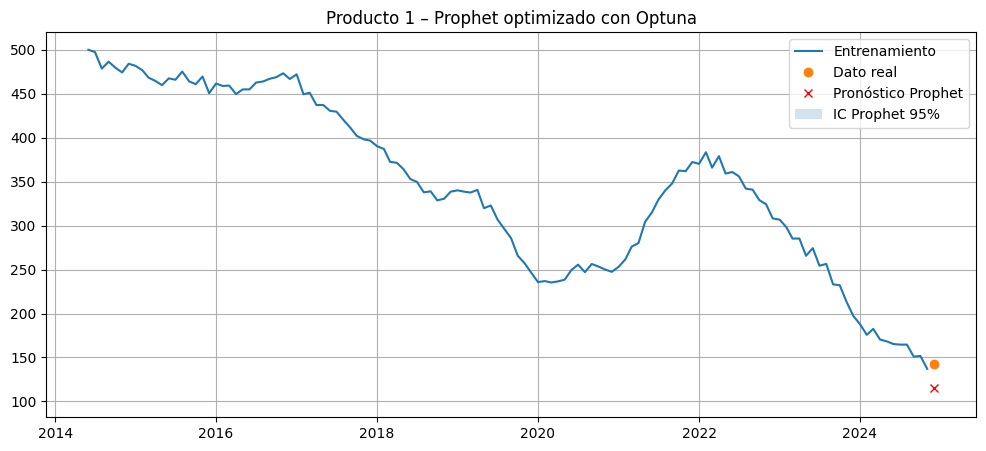

In [42]:
# =========================
# Gráfica – Producto 1
# =========================

plt.figure(figsize=(12, 5))
plt.plot(train_p1.index, train_p1, label="Entrenamiento")
plt.plot(test_p1.index, test_p1, "o", label="Dato real")
plt.plot(pred_p1["ds"], pred_p1["yhat"], "rx", label="Pronóstico Prophet")
plt.fill_between(
    pred_p1["ds"],
    pred_p1["yhat_lower"],
    pred_p1["yhat_upper"],
    alpha=0.2,
    label="IC Prophet 95%"
)
plt.legend()
plt.grid(True)
plt.title("Producto 1 – Prophet optimizado con Optuna")
plt.show()


#### **Producto 2**

In [43]:
# =========================
# Prophet - Producto 2
# =========================

# Serie del producto 2
serie_p2 = data["producto2"]

def objective_prophet_p2(trial):
    """
    Función objetivo para Optuna (Producto 2).
    Misma lógica que Producto 1 pero sobre serie_p2.
    """
    # Hiperparámetros a optimizar
    changepoint_prior_scale = trial.suggest_float(
        "changepoint_prior_scale", 0.001, 0.5, log=True
    )
    seasonality_prior_scale = trial.suggest_float(
        "seasonality_prior_scale", 0.01, 10.0, log=True
    )
    seasonality_mode = trial.suggest_categorical(
        "seasonality_mode", ["additive", "multiplicative"]
    )

    window_size = 115
    n_windows = len(serie_p2) - window_size
    rmse_list = []

    for i in range(n_windows):
        train = serie_p2.iloc[i:i + window_size]
        test  = serie_p2.iloc[i + window_size:i + window_size + 1]

        # Prophet necesita columnas ds, y
        df_train = train.reset_index()
        df_train.columns = ["ds", "y"]

        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode=seasonality_mode,
            changepoint_prior_scale=changepoint_prior_scale,
            seasonality_prior_scale=seasonality_prior_scale
        )

        try:
            m.fit(df_train)
            future = m.make_future_dataframe(periods=1, freq="MS")
            forecast = m.predict(future)
            yhat = forecast["yhat"].iloc[-1]

            rmse = np.sqrt(mean_squared_error(test.values, [yhat]))
            rmse_list.append(rmse)
        except Exception:
            # Penaliza configuraciones que fallen
            return 1e6

    return np.mean(rmse_list)


In [44]:
# Optuna ejecuta 30 combinaciones

sampler_p2 = optuna.samplers.TPESampler(seed=123)
study_p2 = optuna.create_study(direction="minimize", sampler=sampler_p2)
study_p2.optimize(objective_prophet_p2, n_trials=30, show_progress_bar=True)

print("Mejores hiperparámetros Prophet p2:")
print(study_p2.best_params)
print("RMSE promedio Prophet p2:", study_p2.best_value)


[I 2025-12-05 04:50:28,346] A new study created in memory with name: no-name-7c4a0fd6-e448-4e80-9764-56e0f7f9bc06


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-05 04:50:29,567] Trial 0 finished with value: 62.98775807038021 and parameters: {'changepoint_prior_scale': 0.07581400522768209, 'seasonality_prior_scale': 0.07218018732952583, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:30,823] Trial 1 finished with value: 66.85857448185155 and parameters: {'changepoint_prior_scale': 0.08746316087971377, 'seasonality_prior_scale': 0.18591711878786357, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:32,001] Trial 2 finished with value: 87.47839083014235 and parameters: {'changepoint_prior_scale': 0.019861899325201982, 'seasonality_prior_scale': 0.1500902754323389, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 62.98775807038021.


[I 2025-12-05 04:50:33,123] Trial 3 finished with value: 170.49802650554494 and parameters: {'changepoint_prior_scale': 0.0152648778399198, 'seasonality_prior_scale': 0.015101973012087265, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 62.98775807038021.


[I 2025-12-05 04:50:38,592] Trial 4 finished with value: 219.8743059022205 and parameters: {'changepoint_prior_scale': 0.003108420085359684, 'seasonality_prior_scale': 0.03360123720029355, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:39,787] Trial 5 finished with value: 64.82147532383992 and parameters: {'changepoint_prior_scale': 0.05155005795238134, 'seasonality_prior_scale': 3.534234664650462, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 62.98775807038021.


[I 2025-12-05 04:50:40,981] Trial 6 finished with value: 66.41181452890093 and parameters: {'changepoint_prior_scale': 0.08909493583318427, 'seasonality_prior_scale': 0.0930843652400799, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 62.98775807038021.


[I 2025-12-05 04:50:46,756] Trial 7 finished with value: 245.47484780943958 and parameters: {'changepoint_prior_scale': 0.006204765906220318, 'seasonality_prior_scale': 0.7814989008992038, 'seasonality_mode': 'multiplicative'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:47,991] Trial 8 finished with value: 182.28207142341248 and parameters: {'changepoint_prior_scale': 0.014550759888928544, 'seasonality_prior_scale': 0.3027298829337908, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:49,572] Trial 9 finished with value: 190.72477555419528 and parameters: {'changepoint_prior_scale': 0.014148467085264876, 'seasonality_prior_scale': 4.788147156768275, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 62.98775807038021.
[I 2025-12-05 04:50:51,520] Trial 10 finished with value: 61.4872540512984 and parameters: {'changepoint_prior_scale': 0.45367410679323134, 'seasonality_prior_scale': 1.1354490138350288, '

[I 2025-12-05 04:51:00,674] Trial 16 finished with value: 67.48362487077657 and parameters: {'changepoint_prior_scale': 0.19859642579617334, 'seasonality_prior_scale': 2.281697923625817, 'seasonality_mode': 'multiplicative'}. Best is trial 13 with value: 61.13895657329328.


[I 2025-12-05 04:51:05,584] Trial 17 finished with value: 249.58686955260865 and parameters: {'changepoint_prior_scale': 0.001003516769075553, 'seasonality_prior_scale': 1.8435760084195518, 'seasonality_mode': 'multiplicative'}. Best is trial 13 with value: 61.13895657329328.
[I 2025-12-05 04:51:06,769] Trial 18 finished with value: 71.95514668335788 and parameters: {'changepoint_prior_scale': 0.03880550612243332, 'seasonality_prior_scale': 0.41181683694033966, 'seasonality_mode': 'multiplicative'}. Best is trial 13 with value: 61.13895657329328.
[I 2025-12-05 04:51:08,341] Trial 19 finished with value: 64.8793524352184 and parameters: {'changepoint_prior_scale': 0.2852426260365731, 'seasonality_prior_scale': 8.754855816052867, 'seasonality_mode': 'multiplicative'}. Best is trial 13 with value: 61.13895657329328.
[I 2025-12-05 04:51:10,005] Trial 20 finished with value: 60.95448230007715 and parameters: {'changepoint_prior_scale': 0.49965338806837467, 'seasonality_prior_scale': 1.82377

In [45]:
# =========================
# Pronóstico final (mes 127) – Producto 2
# =========================

best_params_prophet_p2 = study_p2.best_params

# Entrenamiento: meses 1–126, prueba = mes 127
train_p2 = serie_p2.iloc[:126]
test_p2  = serie_p2.iloc[126:]

df_train_p2 = train_p2.reset_index()
df_train_p2.columns = ["ds", "y"]

m_best_p2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode=best_params_prophet_p2["seasonality_mode"],
    changepoint_prior_scale=best_params_prophet_p2["changepoint_prior_scale"],
    seasonality_prior_scale=best_params_prophet_p2["seasonality_prior_scale"]
)

m_best_p2.fit(df_train_p2)

future_p2 = m_best_p2.make_future_dataframe(periods=1, freq="MS")
forecast_p2 = m_best_p2.predict(future_p2)

pred_p2 = forecast_p2[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(1)
print("\nPronóstico Prophet (producto 2) para mes 127:")
print(pred_p2)
print("Dato real mes 127:", float(test_p2.iloc[0]))



Pronóstico Prophet (producto 2) para mes 127:
            ds        yhat  yhat_lower  yhat_upper
126 2024-12-01  559.782176  538.025438  579.647296
Dato real mes 127: 676.0580921


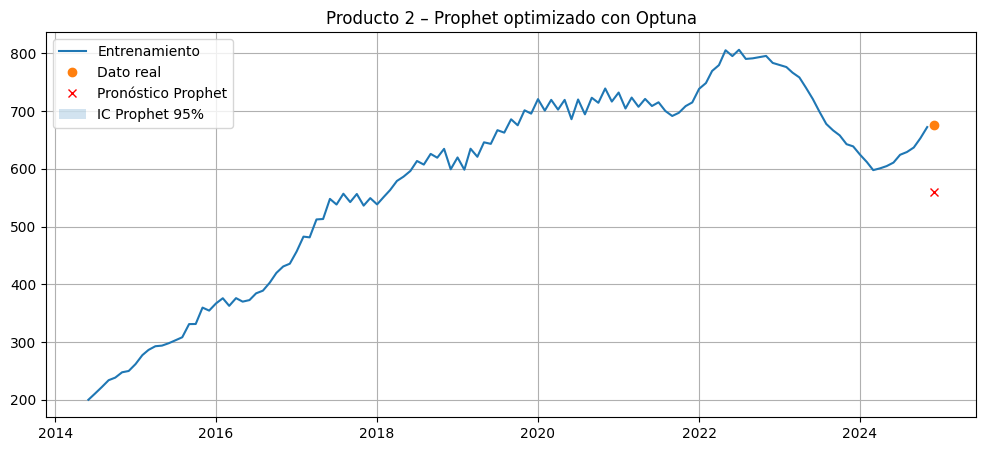

In [46]:
# =========================
# Gráfica – Producto 2
# =========================

plt.figure(figsize=(12, 5))
plt.plot(train_p2.index, train_p2, label="Entrenamiento")
plt.plot(test_p2.index, test_p2, "o", label="Dato real")
plt.plot(pred_p2["ds"], pred_p2["yhat"], "rx", label="Pronóstico Prophet")
plt.fill_between(
    pred_p2["ds"],
    pred_p2["yhat_lower"],
    pred_p2["yhat_upper"],
    alpha=0.2,
    label="IC Prophet 95%"
)
plt.legend()
plt.grid(True)
plt.title("Producto 2 – Prophet optimizado con Optuna")
plt.show()


### **5.6 Modelo VAR**

El modelo VAR permite capturar las interacciones entre las ventas del producto 1 y del producto 2, incorporando rezagos de ambas series en una estructura multivariada.

In [47]:
# =======================================
# 5.9. Modelo VAR (bivariado)
# =======================================

# Se crea un dataframe con ambas series

df_var = data[["producto1", "producto2"]].copy()

In [48]:
# Función de evaluación VAR con ventana móvil

def evaluate_var_rmse(df, target_col, window_size=115, max_lag=5):
    """
    Evalúa un modelo VAR mediante ventana móvil.
    Para cada ventana:
        1. Selecciona el rezago óptimo según AIC.
        2. Ajusta VAR.
        3. Pronostica 1 paso.
        4. Calcula RMSE respecto a la serie objetivo.
    Retorna el RMSE promedio.
    """
    n_windows = len(df) - window_size
    rmses = []
    target_idx = df.columns.get_loc(target_col)

    for i in range(n_windows):
        train = df.iloc[i:i + window_size]
        test  = df.iloc[i + window_size:i + window_size + 1]

        try:
            model = VAR(train)

            # Seleccionar el rezago óptimo por AIC
            sel = model.select_order(maxlags=max_lag)
            lag = sel.selected_orders["aic"]   # ← AQUÍ EL CAMBIO

            # Seguridad por si algo sale raro
            if lag is None or np.isnan(lag):
                lag = 1
            lag = int(lag)
            lag = max(1, min(lag, max_lag, len(train) - 2))

            results = model.fit(lag)

            # Forecast 1 paso adelante
            fc = results.forecast(train.values[-lag:], steps=1)
            y_pred = fc[0, target_idx]
            y_true = test[target_col].iloc[0]

            rmse = np.sqrt(mean_squared_error([y_true], [y_pred]))
            rmses.append(rmse)
        except Exception as e:
            rmses.append(np.nan)

    return np.nanmean(rmses)


In [49]:
# ---------------------------------------------------
# RMSE VAR para cada producto con ventana móvil
# ---------------------------------------------------

rmse_var_p1 = evaluate_var_rmse(df_var, target_col="producto1", window_size=115, max_lag=5)
rmse_var_p2 = evaluate_var_rmse(df_var, target_col="producto2", window_size=115, max_lag=5)

print(f"RMSE promedio VAR - Producto 1: {rmse_var_p1:.4f}")
print(f"RMSE promedio VAR - Producto 2: {rmse_var_p2:.4f}")



RMSE promedio VAR - Producto 1: 5.4178
RMSE promedio VAR - Producto 2: 7.3532


In [50]:
# ---------------------------------------------------
# Pronóstico final (mes 127) con VAR para ambos
# ---------------------------------------------------

# Entrenamos con meses 1–126 y pronosticamos el 127
train_var = df_var.iloc[:126]
test_var  = df_var.iloc[126:127]   # mes 127 real

model_final = VAR(train_var)

sel_final = model_final.select_order(maxlags=5)
lag_final = sel_final.selected_orders["aic"]

if lag_final is None or np.isnan(lag_final):
    lag_final = 1
lag_final = int(lag_final)
lag_final = max(1, min(lag_final, 5, len(train_var) - 2))

results_final = model_final.fit(lag_final)

# Forecast 1 paso adelante
fc_final = results_final.forecast(train_var.values[-lag_final:], steps=1)
pred_p1_var = fc_final[0, 0]  # columna 0 = producto1
pred_p2_var = fc_final[0, 1]  # columna 1 = producto2

real_p1 = test_var["producto1"].iloc[0]
real_p2 = test_var["producto2"].iloc[0]

print("\n=== Pronóstico final VAR (mes 127) ===")
print(f"Producto 1 - Pronóstico: {pred_p1_var:.2f}   Real: {real_p1:.2f}")
print(f"Producto 2 - Pronóstico: {pred_p2_var:.2f}   Real: {real_p2:.2f}")


=== Pronóstico final VAR (mes 127) ===
Producto 1 - Pronóstico: 135.67   Real: 141.99
Producto 2 - Pronóstico: 682.27   Real: 676.06


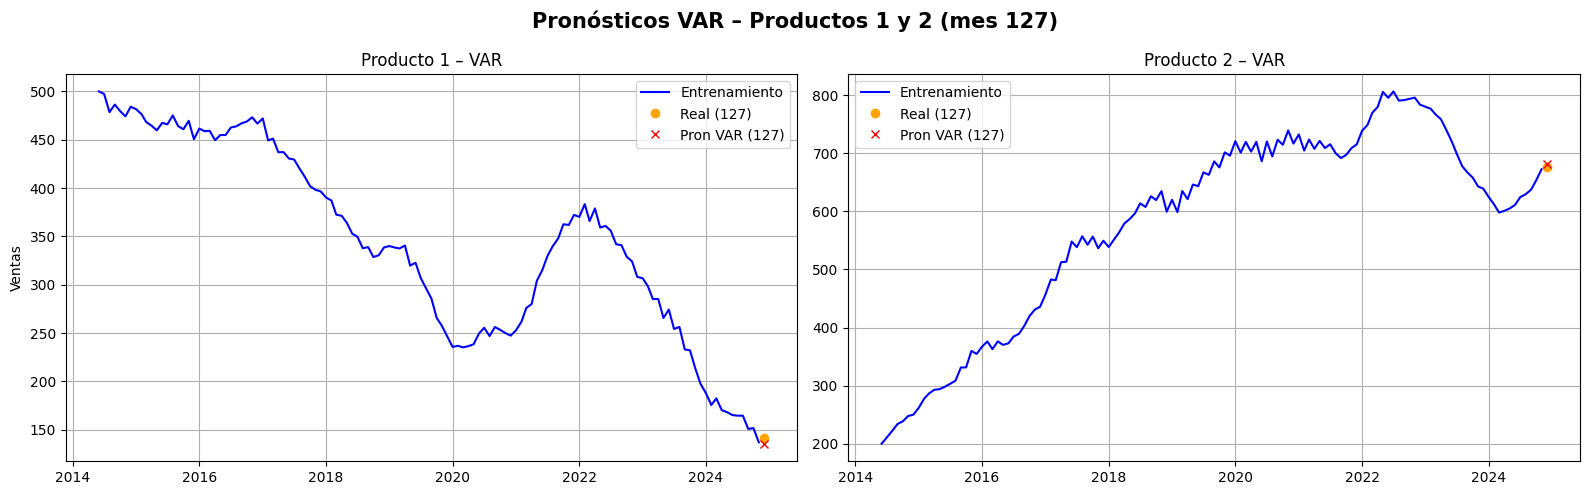

In [51]:
# =========================
# Gráfica – Producto 1 y 2
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# ---- Producto 1 ----
axes[0].plot(train_var.index, train_var["producto1"],
             label="Entrenamiento", color="blue")
axes[0].plot(test_var.index, test_var["producto1"],
             label="Real (127)", color="orange",
             marker="o", linestyle="None")
axes[0].plot(test_var.index, [pred_p1_var],
             label="Pron VAR (127)", color="red",
             marker="x", linestyle="None")
axes[0].set_title("Producto 1 – VAR")
axes[0].set_ylabel("Ventas")
axes[0].grid(True)
axes[0].legend()

# ---- Producto 2 ----
axes[1].plot(train_var.index, train_var["producto2"],
             label="Entrenamiento", color="blue")
axes[1].plot(test_var.index, test_var["producto2"],
             label="Real (127)", color="orange",
             marker="o", linestyle="None")
axes[1].plot(test_var.index, [pred_p2_var],
             label="Pron VAR (127)", color="red",
             marker="x", linestyle="None")
axes[1].set_title("Producto 2 – VAR")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Pronósticos VAR – Productos 1 y 2 (mes 127)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## **6. Elección de mejor modelo**

A continuación presentamos una tabla con los modelos ejecutados para la serie de ventas del producto 1 con su respectivo RMSE calculado.

In [52]:
# Imprimir RMSE faltantes

rmse_ma_p1 = rmse_p1[best_order_p1]   # producto 1 MA
rmse_ma_p2 = rmse_p2[best_order_p2]   # producto 2 MA
rmse_prophet_p1 = study_p1.best_value # producto 1 Prophet
rmse_prophet_p2 = study_p2.best_value # producto 2 Prophet



In [53]:
# =======================================
# Tabla resumen – Producto 1
# =======================================

resumen_p1 = pd.DataFrame([
    {'Modelo': f'MA({best_order_p1})',           'RMSE': rmse_ma_p1},
    {'Modelo': 'ETS (Holt-Winters)',             'RMSE': rmse_HW_product1},
    {'Modelo': best_model1['modelo'],            'RMSE': best_model1['rmse1']},
    {'Modelo': f'ARIMA{best_order1}',            'RMSE': rmse_arima_p1},
    {'Modelo': 'Prophet',                        'RMSE': rmse_prophet_p1},
    { 'Modelo': 'VAR',                            'RMSE':rmse_var_p1}
])
print(resumen_p1.sort_values('RMSE').reset_index(drop=True))


                 Modelo       RMSE
0        ARIMA(3, 1, 2)   4.766611
1    ETS (Holt-Winters)   5.198420
2                   VAR   5.417752
3                 MA(2)   7.925841
4               Prophet  13.887757
5  t^6 + estacionalidad  29.850096


#### **Producto 1**

Para el producto 1, la tabla de resumen muestra que el modelo con menor RMSE promedio bajo el protocolo de ventana móvil es el ARIMA(3, 1, 2).

Aunque se evaluaron alternativas más simples (promedio móvil, tendencia + estacionalidad) y modelos más flexibles (ETS, Prophet, VAR), ARIMA(3,1,2) logra el mejor equilibrio entre complejidad y capacidad de pronóstico.

Por ello, se selecciona ARIMA(3,1,2) como modelo final para pronosticar el mes 128 del producto 1 y se procede a verificar sus supuestos clásicos (normalidad, homocedasticidad y no autocorrelación de los residuos).

In [54]:
# =======================================
# Tabla resumen – Producto 2
# =======================================

resumen_p2 = pd.DataFrame([
    {'Modelo': f'MA({best_order_p2})',           'RMSE': rmse_ma_p2},
    {'Modelo': 'ETS (Holt-Winters)',             'RMSE': rmse_HW_product2},
    {'Modelo': best_model2['modelo'],            'RMSE': best_model2['rmse2']},
    {'Modelo': f'ARIMA{best_order2}',            'RMSE': rmse_arima_p2},
    {'Modelo': 'Prophet',                        'RMSE': rmse_prophet_p2},
    { 'Modelo': 'VAR',                            'RMSE':rmse_var_p2}
])
print(resumen_p2.sort_values('RMSE').reset_index(drop=True))


                   Modelo       RMSE
0      ETS (Holt-Winters)   6.435177
1                     VAR   7.353239
2          ARIMA(3, 3, 3)   7.770159
3                   MA(2)  14.409853
4  t^7 sin estacionalidad  37.298773
5                 Prophet  60.954482


#### **Producto 2**

Para el producto 2, el modelo que obtiene el menor RMSE promedio es la especificación de suavización exponencial ETS con error aditivo, tendencia multiplicativa y sin componente estacional explícito, ajustada mediante optimización bayesiana de sus parámetros de suavizamiento.

En este caso, los modelos ARIMA, de regresión con tendencia y Prophet no logran reducir el RMSE por debajo del obtenido con ETS.

Por tanto, se selecciona ETS (Holt–Winters) como modelo final para pronosticar el mes 128 del producto 2.

### **6.1 Comprobación de supuestos para modelos**

#### **Producto 1 -  Modelo ARIMA**

In [55]:
# =======================================
# Supuestos ARIMA(Producto 1)
# =======================================

# Reajustar el ARIMA con TODA la serie (127 datos)
serie_p1_full = data['producto1']
modelo_arima_full_p1 = ARIMA(serie_p1_full, order=best_order1).fit()

print(modelo_arima_full_p1.summary())

                               SARIMAX Results                                
Dep. Variable:              producto1   No. Observations:                  127
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -429.030
Date:                Fri, 05 Dec 2025   AIC                            870.060
Time:                        04:53:58   BIC                            887.078
Sample:                    06-01-2014   HQIC                           876.974
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6532      0.209     -3.121      0.002      -1.063      -0.243
ar.L2          0.7005      0.127      5.527      0.000       0.452       0.949
ar.L3          0.5937      0.141      4.204      0.0

### I) Normalidad de los residuos

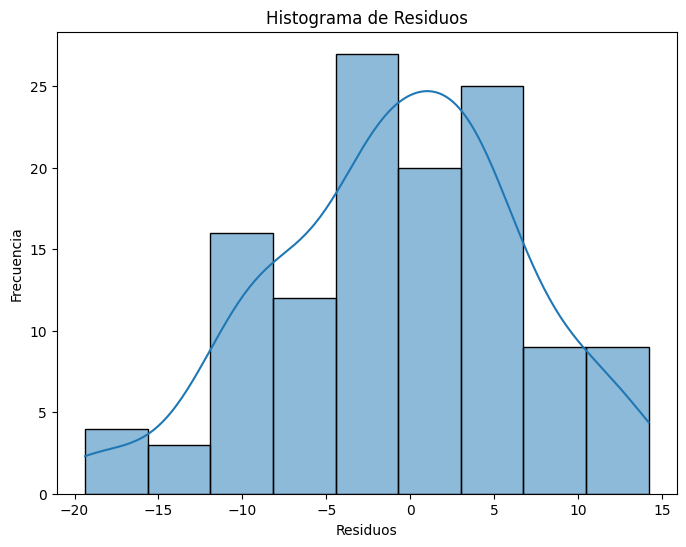

In [56]:
# Residuos del modelo ARIMA
residuals_p1 = modelo_arima_full_p1.resid[2:]
residuals_df_p1 = residuals_p1.reset_index()
residuals_df_p1.columns = ['Mes', 'Residuo']

plt.figure(figsize=(8, 6))
sns.histplot(residuals_p1, kde=True)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()




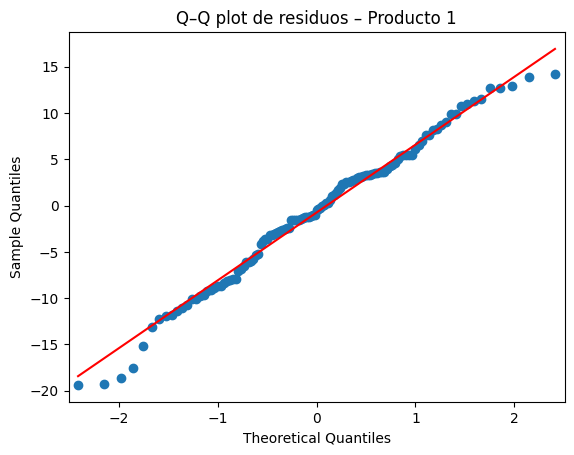

In [57]:
## Q–Q plot (normalidad aproximada)
sm.qqplot(residuals_p1, line="s")
plt.title("Q–Q plot de residuos – Producto 1")
plt.show()

In [58]:
# Prueba Shapiro–Wilk

shapiro_result = stats.shapiro(residuals_df_p1.Residuo)
print(f"Resultados prueba Shapiro: {shapiro_result}")

Resultados prueba Shapiro: ShapiroResult(statistic=np.float64(0.9853003008835314), pvalue=np.float64(0.19594036651065405))


In [59]:
# Prueba Jarque–Bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals_p1)

print("=== Prueba de Jarque–Bera ===")
print(f"Estadístico JB: {jb_stat:.4f}")
print(f"p-value:        {jb_pvalue:.4f}")

if jb_pvalue > 0.05:
    print("\nConclusión: No se rechaza H0 → Los residuos NO difieren de la normalidad.")
else:
    print("\nConclusión: Se rechaza H0 → Los residuos NO son normales.")

=== Prueba de Jarque–Bera ===
Estadístico JB: 1.7553
p-value:        0.4158

Conclusión: No se rechaza H0 → Los residuos NO difieren de la normalidad.


En el histograma y el Q–Q plot se aprecia cierta asimetría en la distribución de los residuos. No obstante, tanto la prueba de Shapiro–Wilk como la de Jarque–Bera arrojan p-valores superiores a 0.05.

Bajo este nivel de significancia, no se rechaza la hipótesis nula de normalidad, por lo que no hay evidencia estadísticamente significativa para afirmar que los residuos del modelo ARIMA(3,1,2) se desvíen de una distribución normal.

### II) Homocedasticidad de los residuos

In [61]:
# Ljung–Box sobre residuos al cuadrado (para detectar ARCH)
lb_test = sm.stats.acorr_ljungbox(residuals_p1**2, lags=[12], return_df=True)

print("=== Prueba de Ljung–Box sobre residuos^2 ===")
print(lb_test)

p_value = lb_test["lb_pvalue"].iloc[0]

print(f"\nValor p: {p_value:.5f}")

if p_value > 0.05:
    print("Conclusión: No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.")
else:
    print("Conclusión: Se rechaza la hipótesis nula: Los residuos presentan heterocedasticidad..")


=== Prueba de Ljung–Box sobre residuos^2 ===
      lb_stat  lb_pvalue
12  14.311585   0.281255

Valor p: 0.28126
Conclusión: No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.


In [62]:
# Prueba de Breusch-Pagan

exog = sm.add_constant(range(len(residuals_p1)))  # Variable independiente para la prueba
test = sms.het_breuschpagan(residuals_p1, exog)

# Los resultados de la prueba de Breusch-Pagan
test_stat = test[0]  # estadístico de la prueba
p_value = test[1]    # valor p
f_stat = test[2]     # estadístico F
f_p_value = test[3]  # valor p del estadístico F

print(f"Breusch-Pagan test statistic: {test_stat}")
print(f"Breusch-Pagan p-value: {p_value}")

# Evaluar y reportar la heterocedasticidad basada en el valor p
if p_value > 0.05:
    print("No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.")
else:
    print("Se rechaza la hipótesis nula: Los residuos presentan heterocedasticidad.")

Breusch-Pagan test statistic: 1.7696769120706808
Breusch-Pagan p-value: 0.18342206876588701
No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.


In [63]:
# Prueba de ARCH para heterocedasticidad
arch_test = het_arch(residuals_p1)

# Extraer el estadístico de prueba y el valor p
arch_statistic = arch_test[0]
arch_p_value = arch_test[1]

# Mostrar los resultados
print(f'ARCH Test Statistic: {arch_statistic}')
print(f'p-value: {arch_p_value:.10f}')  # Mostrar el valor p con mayor precisión

# Evaluar y reportar la heterocedasticidad basada en el valor p
if arch_p_value > 0.05:
    print("No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.")
else:
    print("Se rechaza la hipótesis nula: Los residuos presentan heterocedasticidad.")

ARCH Test Statistic: 13.600256960685268
p-value: 0.1920181257
No se rechaza la hipótesis nula: Los residuos no presentan heterocedasticidad.


Para evaluar la homocedasticidad se aplicaron la prueba de Ljung–Box sobre los residuos al cuadrado, la prueba de Breusch–Pagan y la prueba de ARCH.

En las tres pruebas, los p-valores resultan mayores a 0.05, por lo que no se rechaza la hipótesis nula de varianza constante.

En consecuencia, existe evidencia estadística para afirmar que los residuos del modelo presentan un comportamiento homocedástico.

### III) Autocorrelación de los residuos

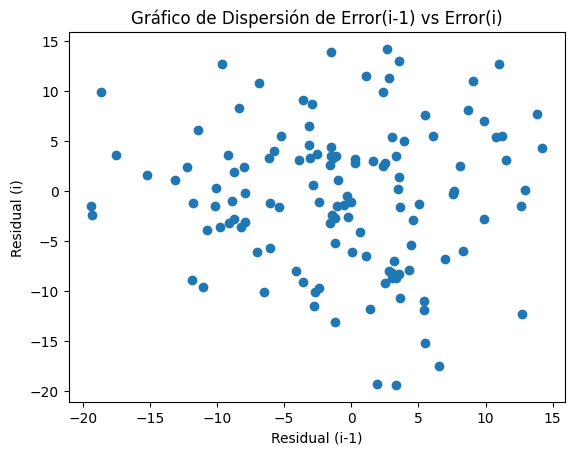

In [64]:
# Gráfico de dispersión de los residuos
residuals_i_1 = residuals_p1[:-1]
residuals_i = residuals_p1[1:]

plt.scatter(residuals_i_1, residuals_i)
plt.title('Gráfico de Dispersión de Error(i-1) vs Error(i)')
plt.xlabel('Residual (i-1)')
plt.ylabel('Residual (i)')
plt.show()

In [65]:
signo = residuals_df_p1.Residuo>0
runstest_1samp(signo, correction=False)

(np.float64(-0.2518618550977627), np.float64(0.8011478445016038))

Gráficamente, el diagrama de dispersión de Residual(i−1) vs Residual(i) no muestra un patrón evidente de dependencia lineal entre errores consecutivos.

Esta impresión se confirma al aplicar la prueba de rachas de Wald–Wolfowitz, cuyo p-valor es superior a 0.05. Bajo este criterio, no se rechaza la hipótesis nula de ausencia de autocorrelación, por lo que se concluye que los errores del modelo ARIMA(3,1,2) no están autocorrelacionados.

## **7. Pronósticos para mejores modelos**

#### **Producto 1**

In [66]:
# ================================
# PRODUCTO 1 - ARIMA FINAL
# Entrenado con TODA la serie (127 datos)
# Pronóstico del mes 128
# ================================

serie_p1_full = data["producto1"]

modelo_arima_full_p1 = ARIMA(serie_p1_full, order=best_order1)
res_arima_full_p1 = modelo_arima_full_p1.fit()

forecast_res_128_p1 = res_arima_full_p1.get_forecast(steps=1)
pred_mean_128_p1 = forecast_res_128_p1.predicted_mean
conf_int_128_p1 = forecast_res_128_p1.conf_int(alpha=0.05)

idx_128_p1 = pred_mean_128_p1.index[0]
point_128_p1 = float(pred_mean_128_p1.iloc[0])
lower_128_p1 = float(conf_int_128_p1.iloc[0, 0])
upper_128_p1 = float(conf_int_128_p1.iloc[0, 1])

print("Pronóstico ARIMA producto 1 – dato 128:")
print(f"Point forecast: {point_128_p1:.2f}")
print(f"IC 95%: [{lower_128_p1:.2f}, {upper_128_p1:.2f}]")

Pronóstico ARIMA producto 1 – dato 128:
Point forecast: 132.48
IC 95%: [118.28, 146.69]


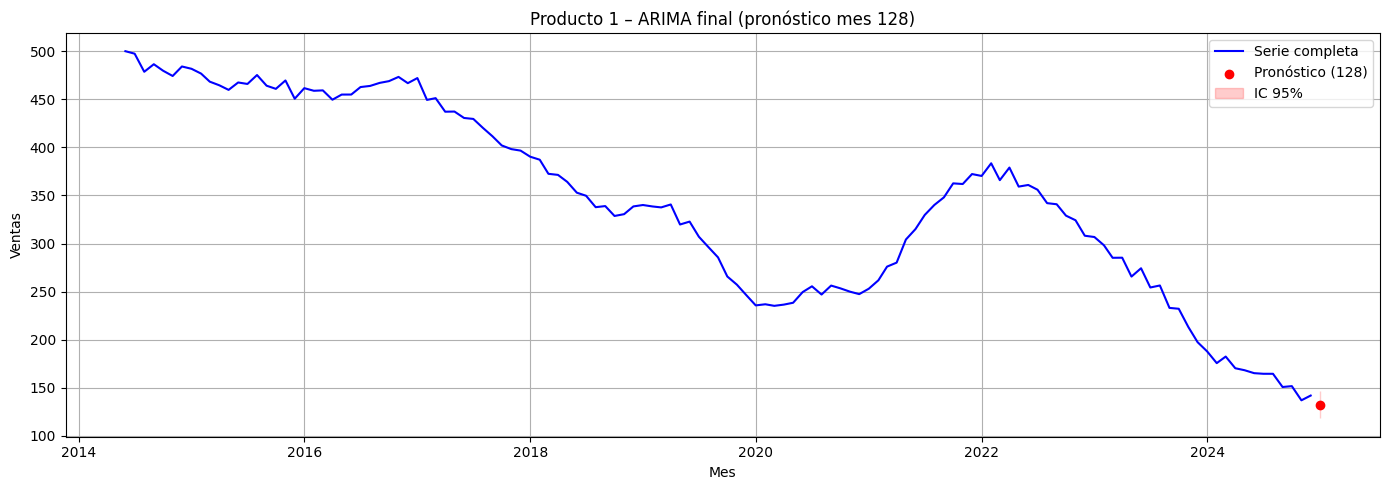

In [67]:
# ================================
# Gráfico final - Producto 1
# ================================
plt.figure(figsize=(14, 5))

# Serie completa
plt.plot(serie_p1_full.index, serie_p1_full,
         label="Serie completa", color="blue")

# Punto de pronóstico (mes 128)
plt.scatter(idx_128_p1, point_128_p1,
            color="red", label="Pronóstico (128)", zorder=3)

# Intervalo de confianza 95 %
plt.fill_between([idx_128_p1],
                 [lower_128_p1],
                 [upper_128_p1],
                 color="red", alpha=0.2, label="IC 95%")

plt.title("Producto 1 – ARIMA final (pronóstico mes 128)")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### **Producto 2**

In [68]:
# ======================================
# PRODUCTO 2 - ETS FINAL (Holt-Winters)
# Entrenado con TODOS los datos (127)
# Pronóstico del mes 128
# ======================================

serie_p2_full = data["producto2"]

ets_model_full_p2 = ETSModel(
    endog=serie_p2_full,
    error=best_error_p2,
    trend=best_trend_p2,
    seasonal=best_seasonal_p2
)

params_full_p2 = {"smoothing_level": best_alpha_p2}
if best_trend_p2 is not None:
    params_full_p2["smoothing_trend"] = best_beta_p2
if best_seasonal_p2 is not None:
    params_full_p2["smoothing_seasonal"] = best_gamma_p2

ets_full_res_p2 = ets_model_full_p2.fit_constrained(params_full_p2)

# Pronóstico del mes 128
forecast_128_p2 = ets_full_res_p2.forecast(steps=1)
idx_128 = forecast_128_p2.index[0]

# PredictionResults
pred_full_p2 = ets_full_res_p2.get_prediction(start=idx_128, end=idx_128)
sf = pred_full_p2.summary_frame(alpha=0.05)

print("Columnas de summary_frame():", sf.columns)

# --- Extraer punto e intervalos de forma robusta ---

# Punto de pronóstico
if "mean" in sf.columns:
    point_128 = sf["mean"].iloc[0]
elif "predicted_mean" in sf.columns:
    point_128 = sf["predicted_mean"].iloc[0]
else:
    # Por si acaso: primera columna numérica
    point_128 = sf.select_dtypes(include=[np.number]).iloc[0, 0]

# Columnas que contienen "lower" y "upper"
lower_cols = [c for c in sf.columns if "lower" in c.lower()]
upper_cols = [c for c in sf.columns if "upper" in c.lower()]

if lower_cols and upper_cols:
    lower_128 = sf[lower_cols[0]].iloc[0]
    upper_128 = sf[upper_cols[0]].iloc[0]
else:
    # Si por alguna razón no hay columnas de IC, usamos NaN
    lower_128 = np.nan
    upper_128 = np.nan

print("Pronóstico ETS producto 2 – dato 128")
print(f"Point forecast: {point_128:.2f}")
print(f"IC 95%: [{lower_128:.2f}, {upper_128:.2f}]")

Columnas de summary_frame(): Index(['mean', 'mean_numerical', 'pi_lower', 'pi_upper'], dtype='object')
Pronóstico ETS producto 2 – dato 128
Point forecast: 681.87
IC 95%: [642.51, 722.59]


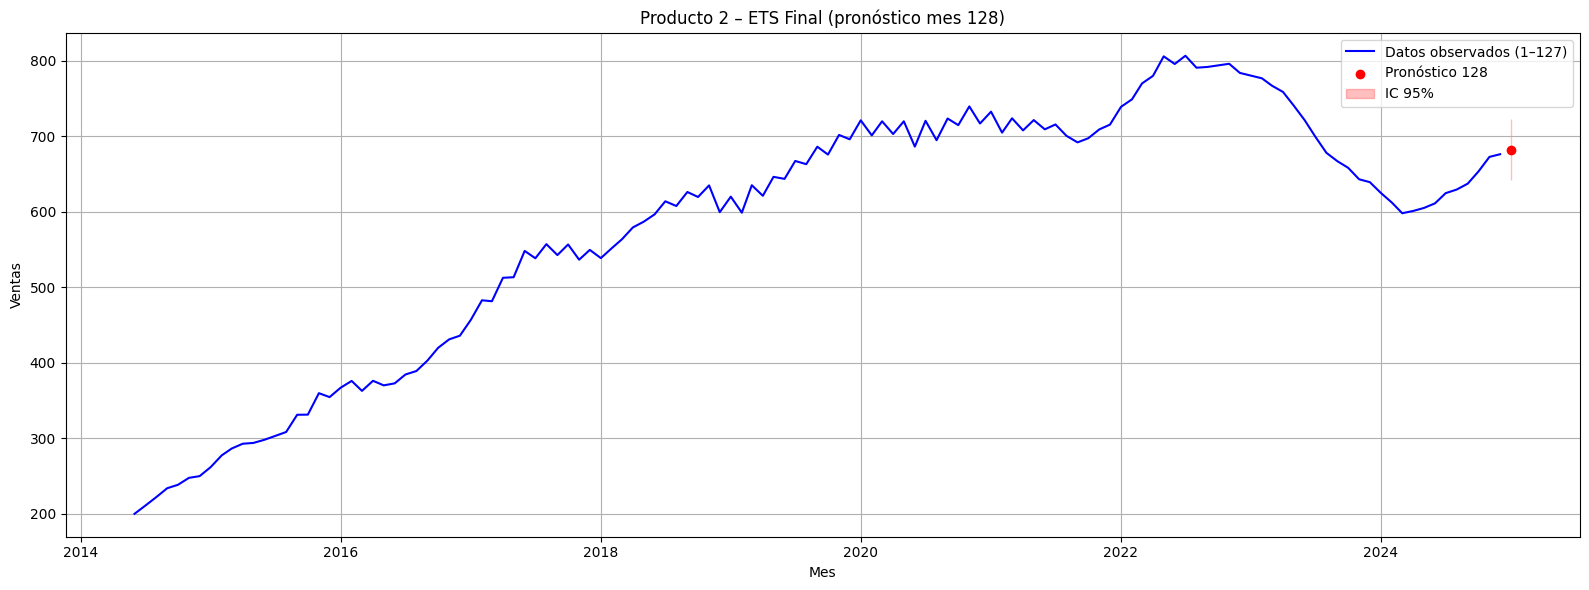

In [69]:
# ================================
# Gráfico final - Producto 2
# ================================
plt.figure(figsize=(16, 6))
plt.plot(serie_p2_full.index, serie_p2_full,
         color="blue", label="Datos observados (1–127)")

plt.scatter(idx_128, point_128, color="red", label="Pronóstico 128")

if not np.isnan(lower_128) and not np.isnan(upper_128):
    plt.fill_between([idx_128], [lower_128], [upper_128],
                     alpha=0.25, color="red", label="IC 95%")

plt.title("Producto 2 – ETS Final (pronóstico mes 128)")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

En resumen:

- Para el producto 1, el modelo seleccionado ARIMA(3,1,2) pronostica para el mes 128 unas ventas puntuales de aproximadamente 132 unidades, con un intervalo de confianza al 95% que refleja la incertidumbre inherente al proceso de pronóstico.

- Para el producto 2, el modelo ETS seleccionado proyecta para el mes 128 unas ventas de aproximadamente 682 unidades, también acompañado de un intervalo de confianza al 95%.

Estos resultados permiten a la compañía anticipar el comportamiento de sus dos productos estrella en el corto plazo y sirven como insumo para la planeación de inventarios, producción y estrategias comerciales.